## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

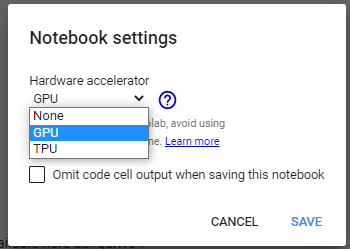

### **RUN THIS** - Mount your google drive

If you have some images to train on, mount your drive. Alternatively scroll down and download the example images.

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.


Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


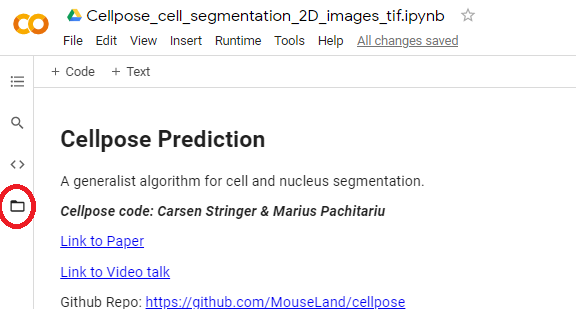

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

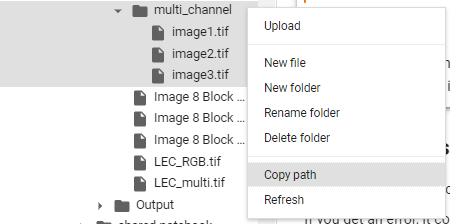

Copy and paste this path in the **dir** string below

# Observing data

In [ ]:
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

img_path = Path(r"Z:\AD images for Margaret and Shizuka\EXPI 59\cellpose_sam_expi59")
img = tifffile.imread(img_path)

print(f"Img shape: {img.shape}")

num_channels = img.shape[-1]

plt.figure(figsize=(15, 5))

for c in range(num_channels):
    plt.subplot(1, num_channels, c+1)
    plt.imshow(img[..., c], cmap='gray')
    plt.title(f"Channel {c}")
    plt.axis('off')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Z:\\AD images for Margaret and Shizuka\\EXPI 59\\cellpose_sam_expi59'

# Dataset Preparation


## **RUN THIS** - Set up


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git
!pip install scikit-image

Check GPU and instantiate model - will download weights.

In [ ]:
# import numpy as np
# from cellpose import models, core, io, plot
# from pathlib import Path
# from tqdm import trange
# import matplotlib.pyplot as plt

# io.logger_setup() # run this to get printing of progress

# #Check if colab notebook instance has GPU access
# if core.use_gpu()==False:
#   raise ImportError("No GPU access, change your runtime")

# model = models.CellposeModel(gpu=True)

Input directory with your images (if you have them, otherwise use sample images):

In [ ]:
# # *** change to your google drive folder path ***
# train_dir =  "/content/drive/MyDrive/FISH-ML2/cellpose-sam/train"
# if not Path(train_dir).exists():
#   raise FileNotFoundError("directory does not exist")

# test_dir ="/content/drive/MyDrive/FISH-ML2/cellpose-sam/test"# optionally you can specify a directory with test files

# # *** change to your mask extension ***
# masks_ext = "_seg.npy"
# # ^ assumes images from Cellpose GUI, if labels are tiffs, then "_masks.tif"

# # list all files
# files = [f for f in Path(train_dir).glob("*") if "_masks" not in f.name and "_flows" not in f.name and "_seg" not in f.name]

# if(len(files)==0):
#   raise FileNotFoundError("no files found, did you specify the correct folder and extension?")
# else:
#   print(f"{len(files)} files in folder:")

# for f in files:
#   print(f.name)

## Preprocessing data

In [ ]:
from skimage.restoration import estimate_sigma
import tifffile
import numpy as np
from pathlib import Path
import cv2

# ----- HELPER PREPROCESSING FUNCTIONS -----
def remove_outliers(img, k=18.0, use_median=False, max_clip_frac=1e-2):
    x = img.astype(np.float32)

    mean = np.mean(x)
    std = np.std(x)
    thresh = mean + k * std

    # ---- Compute how many pixels would be clipped ----
    mask = x > thresh
    clip_frac = mask.mean()  # between 0 and 1

    # ---- Decide whether to actually clip ----
    if (clip_frac == 0) or (clip_frac > max_clip_frac):
        # Either nothing to clip, or "too many" pixels above thresh
        # -> treat as no extreme outliers and skip clipping
        x_clipped = x
    else:
        # safe to treat as extreme outliers
        x_clipped = np.minimum(x, thresh)

    # ---- Normalize after clipping (to 0..1) ----
    x_min = x_clipped.min()
    x_max = x_clipped.max()
    x_norm = (x_clipped - x_min) / (x_max - x_min + 1e-6)
    return x_norm

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def apply_clahe(img, clip_limit=4.0, tile_size=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(img)

def preprocess_image(img):
    # img.shape

    # img: (H, W, 3)
    ch0 = img[..., 0]  # e.g. DAPI
    ch1 = img[..., 1]  # 647
    ch2 = img[..., 2]  # 488

    # --- CHANNEL PROCESSING ---

    # Nucleus
    ch0_proc = ch0 # no preprocessing for nucleus

    # 647
    ch1_rem = remove_outliers(ch1, k=20)
    ch1_norm = normalize_to_uint8(ch1_rem)
    ch1_clahe = apply_clahe(ch1_norm, clip_limit=2.0)
    ch1_proc = ch1_clahe

    # 488
    ch2_rem = remove_outliers(ch2, k=20)
    ch2_norm = normalize_to_uint8(ch2_rem)
    ch2_clahe = apply_clahe(ch2_norm, clip_limit=4.0)

    sigma_est = estimate_sigma(ch2_clahe)
    sigma_norm = sigma_est + 3.0
    sigma_weak = sigma_est - 10.0 # TODO check with margaret - is sigma_weak used somewhere?

    ch2_bilat = cv2.bilateralFilter(ch2_clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
    ch2_proc = ch2_bilat

    out = np.stack([ch0_proc, ch1_proc, ch2_proc], axis=-1)
    return out




In [ ]:
# Check NAS path accessibility and process images
from pathlib import Path
import tifffile

# Set NAS path (update if using UNC path if Z: does not work)
nas_path = Path(r"Z:\AD images for Margaret and Shizuka\EXPI 59\cellpose_sam_expi59")

print("Exists:", nas_path.exists())
print("Is dir:", nas_path.is_dir())
if nas_path.exists():
    print("Contents:", list(nas_path.iterdir()))
else:
    print("Not accessible from this environment.")

# If accessible, proceed with processing
if nas_path.exists() and nas_path.is_dir():
    train_src_dir = nas_path / "train"
    test_src_dir = nas_path / "test"
    proc_dir = nas_path / "image_proc"
    proc_dir.mkdir(parents=True, exist_ok=True)  # Create all parent directories if needed

    # Process training images
    if train_src_dir.exists():
        for tif_path in train_src_dir.glob("*.tif"):
            img = tifffile.imread(tif_path)
            proc = preprocess_image(img)
            tifffile.imwrite(proc_dir / tif_path.name, proc, photometric='minisblack')
            print("Finished preprocessing and writing:", tif_path)
    else:
        print("Training source directory does not exist:", train_src_dir)

    # Process testing images
    if test_src_dir.exists():
        for tif_path in test_src_dir.glob("*.tif"):
            img = tifffile.imread(tif_path)
            proc = preprocess_image(img)
            tifffile.imwrite(proc_dir / tif_path.name, proc, photometric='minisblack')
            print("Finished preprocessing and writing:", tif_path)
    else:
        print("Testing source directory does not exist:", test_src_dir)
else:
    print("NAS path is not accessible. Please check mapping and permissions.")

### Check if train_proc has correct preprocessed images

In [ ]:
import tifffile
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc/EXP251009COLA01_img_001.tif"
img = tifffile.imread(img_path)

print(f"Img shape: {img.shape}")

num_channels = img.shape[-1]

plt.figure(figsize=(15, 5))

for c in range(num_channels):
    plt.subplot(1, num_channels, c+1)
    plt.imshow(img[..., c], cmap='gray')
    plt.title(f"Channel {c}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Weakening Nucleus Signal

### Observing different weights

In [ ]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

# Choose whether to test on train_proc or train
TEST_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")  # or train
tif_paths = sorted(TEST_DIR.glob("*.tif"))
assert len(tif_paths) > 0, f"No tif files found in {TEST_DIR}"

tif_path = tif_paths[0]
img = tifffile.imread(str(tif_path))
print("Testing:", tif_path.name, "shape:", img.shape, "dtype:", img.dtype)

NUC_IDX, CYTO_IDX = 0, 2

def robust_norm(x, p_lo=1, p_hi=99, eps=1e-8): # more robust than min/max because hot pixels or noise spikes won’t define the scale
    lo, hi = np.percentile(x, [p_lo, p_hi])
    x = (x - lo) / (hi - lo + eps)
    return np.clip(x, 0, 1) # clamps below 0 → 0 and above 1 → 1

def rebalance_channels(img, nuc_idx=0, cyto_idx=1, nuc_weight=0.50, gamma_nuc=None, nuc_p_hi=99):
    out = img.astype(np.float32, copy=True)
    out[..., cyto_idx] = robust_norm(out[..., cyto_idx], 1, 99)
    out[..., nuc_idx]  = robust_norm(out[..., nuc_idx],  1, nuc_p_hi)
    out[..., nuc_idx] *= nuc_weight
    if gamma_nuc is not None:
        out[..., nuc_idx] = np.clip(out[..., nuc_idx], 0, 1) ** gamma_nuc
    return np.clip(out, 0, 1).astype(np.float32)

# configs to compare
CONFIGS = [
    ("w=0.70,g=None", 0.70, None, 99),
    ("w=0.50,g=None",  0.50, None,  99),
    ("w=0.30,g=None", 0.30, None, 99),
    ("w=0.20,g=None",  0.20, None,  99),
]

raw_n = robust_norm(img[..., NUC_IDX].astype(np.float32))
raw_c = robust_norm(img[..., CYTO_IDX].astype(np.float32))

fig, ax = plt.subplots(len(CONFIGS)+1, 3, figsize=(15, 4*(len(CONFIGS)+1)))

# raw row
ax[0,0].imshow(raw_n, cmap="gray", vmin=0, vmax=1); ax[0,0].set_title("Raw nuc (display)"); ax[0,0].axis("off")
ax[0,1].imshow(raw_c, cmap="gray", vmin=0, vmax=1); ax[0,1].set_title("Raw cyto (display)"); ax[0,1].axis("off")
ax[0,2].imshow(np.stack([raw_c, raw_n, np.zeros_like(raw_n)], -1)); ax[0,2].set_title("Raw combined"); ax[0,2].axis("off")

print("\nConfig stats (after rebalance):")
print("="*70)

for i, (name, w, g, p_hi) in enumerate(CONFIGS, start=1):
    out = rebalance_channels(img, nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX, nuc_weight=w, gamma_nuc=g, nuc_p_hi=p_hi)

    n = out[..., NUC_IDX]
    c = out[..., CYTO_IDX]

    print(f"{name:14s} | nuc mean={n.mean():.4f} max={n.max():.4f} | cyto mean={c.mean():.4f} max={c.max():.4f} | mean ratio={ (n.mean()/(c.mean()+1e-8)):.3f}")

    ax[i,0].imshow(n, cmap="gray", vmin=0, vmax=1); ax[i,0].set_title(f"Nuc {name}"); ax[i,0].axis("off")
    ax[i,1].imshow(c, cmap="gray", vmin=0, vmax=1); ax[i,1].set_title(f"Cyto {name}"); ax[i,1].axis("off")
    ax[i,2].imshow(np.stack([c, n, np.zeros_like(n)], -1)); ax[i,2].set_title(f"Combined {name}"); ax[i,2].axis("off")

plt.tight_layout()
plt.show()


### Update dataset with new data of weakened nucleus signal

In [ ]:
from pathlib import Path

p = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
print("exists:", p.exists(), "is_dir:", p.is_dir())
print("num tif:", len(list(p.glob("*.tif"))))
print("num npy:", len(list(p.glob("*_seg.npy"))))


In [ ]:
# ===== Option B: Store all variants ONCE, select at training time (no file rewriting) =====
# This script:
# 1) (one-time) populates each *_seg.npy with:
#       d["img_base"]       : normalized base image (float32 [0,1]) before nucleus weighting
#       d["img_rebalanced"] : dict of weighted variants {"w0.30": ..., "w0.50": ..., "w0.70": ...}
#       d["rebalance_meta"] : parameters used to generate these
# 2) (training-time) shows how to load and pick a weight without modifying files:
#       img = d["img_rebalanced"]["w0.50"]

import numpy as np
import tifffile
from pathlib import Path
from tqdm import tqdm

# -----------------------------
# Paths
# -----------------------------
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

# -----------------------------
# Channel indices in TIFF (H,W,C)
# Adjust if needed
# -----------------------------
NUC_IDX, CYTO_IDX = 0, 2

# -----------------------------
# Variant settings
# -----------------------------
WEIGHTS = [0.30, 0.50, 0.70]
GAMMA_NUC = None
NUC_P_HI = 99

# -----------------------------
# Helpers
# -----------------------------
def fix_channel_axis(img: np.ndarray) -> np.ndarray:
    """Convert (C,H,W) -> (H,W,C) if needed."""
    if img.ndim == 3 and img.shape[0] in (2, 3) and img.shape[-1] not in (2, 3):
        img = np.moveaxis(img, 0, -1)
    return img

def robust_norm(x: np.ndarray, p_lo=1, p_hi=99, eps=1e-8) -> np.ndarray:
    """Percentile normalize -> [0,1]."""
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_lo, p_hi])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)

def make_img_base(img_pre: np.ndarray, nuc_idx=0, cyto_idx=1, nuc_p_hi=99) -> np.ndarray:
    """
    Normalize nucleus and cytoplasm channels to [0,1] (per-channel robust norm),
    leaving other channels (if any) untouched except clipping to [0,1] if they are out of range.
    If you want to normalize all channels, adjust accordingly.
    """
    out = img_pre.astype(np.float32, copy=True)

    # Normalize just the nucleus + cyto channels (common for training)
    out[..., cyto_idx] = robust_norm(out[..., cyto_idx], p_lo=1, p_hi=99)
    out[..., nuc_idx]  = robust_norm(out[..., nuc_idx],  p_lo=1, p_hi=nuc_p_hi)

    # If there are extra channels, you can either:
    #  - leave them as-is, or
    #  - normalize them too.
    # For safety, clip all channels to [0,1] to avoid RGB plotting issues / downstream assumptions.
    return np.clip(out, 0, 1).astype(np.float32)

def apply_nucleus_weight(img_base: np.ndarray, nuc_idx=0, weight=0.3, gamma=None) -> np.ndarray:
    """
    Apply nucleus scaling on normalized base image.
    Output stays float32 [0,1].
    """
    out = img_base.copy()
    out[..., nuc_idx] *= weight
    if gamma is not None:
        out[..., nuc_idx] = np.clip(out[..., nuc_idx], 0, 1) ** gamma
    return np.clip(out, 0, 1).astype(np.float32)

def store_variants_in_npy(proc_dir: Path, label: str, overwrite=True) -> dict:
    """
    One-time step: for each proc .tif, write variants into corresponding *_seg.npy.

    overwrite=False means:
      - if img_rebalanced already exists, we skip (safer)
    """
    tif_paths = sorted(proc_dir.glob("*.tif"))
    print(f"\n{label}: found {len(tif_paths)} .tif files in {proc_dir}")

    updated = skipped_exists = missing_npy = errors = 0

    for tif_path in tqdm(tif_paths, desc=f"Store variants {label}"):
        npy_path = Path(str(tif_path.with_suffix("")) + "_seg.npy")
        if not npy_path.exists():
            missing_npy += 1
            continue

        try:
            d = np.load(str(npy_path), allow_pickle=True).item()

            if (not overwrite) and ("img_rebalanced" in d) and isinstance(d["img_rebalanced"], dict) and len(d["img_rebalanced"]) > 0:
                skipped_exists += 1
                continue

            img_pre = fix_channel_axis(tifffile.imread(str(tif_path)))
            if not (img_pre.ndim == 3 and img_pre.shape[-1] >= 2):
                raise ValueError(f"Expected (H,W,C>=2) image, got {img_pre.shape}")

            img_base = make_img_base(img_pre, nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX, nuc_p_hi=NUC_P_HI)

            variants = {}
            for w in WEIGHTS:
                key = f"w{w:.2f}"
                variants[key] = apply_nucleus_weight(img_base, nuc_idx=NUC_IDX, weight=w, gamma=GAMMA_NUC)

            d["img_base"] = img_base
            d["img_rebalanced"] = variants
            d["rebalance_meta"] = {
                "source_proc_tif": str(tif_path),
                "nuc_idx": int(NUC_IDX),
                "cyto_idx": int(CYTO_IDX),
                "nuc_p_hi": int(NUC_P_HI),
                "gamma_nuc": GAMMA_NUC,
                "weights": [float(w) for w in WEIGHTS],
                "method": "img_base=per-channel robust_norm(p1,p99) then apply nucleus linear weight on img_base",
                "applied_to": label
            }

            # IMPORTANT: Option B means we do NOT set d["img"] here.
            # Downstream training decides which variant to use.

            np.save(str(npy_path), d)
            updated += 1

        except Exception as e:
            errors += 1
            print(f"\nERROR on {tif_path.name}: {repr(e)}")

    print(f"\n{label} SUMMARY")
    print("=" * 60)
    print(f"Updated:              {updated}")
    print(f"Skipped (already had): {skipped_exists}")
    print(f"Missing _seg.npy:     {missing_npy}")
    print(f"Errors:               {errors}")

    return {
        "label": label,
        "updated": updated,
        "skipped_exists": skipped_exists,
        "missing_npy": missing_npy,
        "errors": errors
    }

# -----------------------------
# (1) ONE-TIME: store variants in all files
# -----------------------------
train_stats = store_variants_in_npy(TRAIN_PROC_DIR, "TRAIN_PROC", overwrite=True)
test_stats  = store_variants_in_npy(TEST_PROC_DIR,  "TEST_PROC",  overwrite=True)

print("\nOVERALL")
print(train_stats)
print(test_stats)


### **RUN THIS** - Pick nucleus weighting factor for training

In [ ]:
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
example_npy = sorted(TRAIN_PROC_DIR.glob("*_seg.npy"))[0]
d = np.load(str(example_npy), allow_pickle=True).item()

WEIGHT_TO_USE = 0.30
key = f"w{WEIGHT_TO_USE:.2f}"   # <-- "w0.50"
REB_KEY = key
print(">>> Training will use nucleus weight:", key)

print("available keys:", list(d["img_rebalanced"].keys()))
assert key in d["img_rebalanced"], f"{key} not found. Available: {list(d['img_rebalanced'].keys())}"

img_for_training = d["img_rebalanced"][key]
print("selected:", key, "shape:", img_for_training.shape, "dtype:", img_for_training.dtype,
      "min/mean/max:", float(img_for_training.min()), float(img_for_training.mean()), float(img_for_training.max()))


In [ ]:
nuc = img_for_training[..., 0]
cyto = img_for_training[..., 1]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(nuc, cmap="gray", vmin=0, vmax=1)
plt.title("Weighted Nucleus")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cyto, cmap="gray", vmin=0, vmax=1)
plt.title("Preprocessed Cytoplasm")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.stack([cyto, nuc, np.zeros_like(nuc)], -1))
plt.title("Combined")
plt.axis("off")

plt.show()


## Determining cells without GT

### Try out

In [ ]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

from skimage import filters, morphology, measure
from skimage.filters import gaussian
from skimage.segmentation import find_boundaries
from scipy.ndimage import (
    binary_dilation, binary_fill_holes, binary_closing, binary_opening, label as cc_label
)

# ===== paths =====
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

# ===== channels =====
NUC_IDX = 0
CYTO_IDX = 1

# ===== behavior =====
OVERWRITE_IGNORE = False

# ===== parameters =====
IGNORE_PARAMS = dict(
    nuc_idx=NUC_IDX,
    cyto_idx=CYTO_IDX,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_component_area=300,
    max_component_area=200000,
    hole_area=300,               # kept for compatibility; NOT used when step 3 is skipped
    use_nucleus_gate=True,
    nuc_dilate_radius=18,
    min_nuc_overlap_pixels=10,
    min_fg_pixels_for_otsu=500,
)

FINALIZE_PARAMS = dict(
    dilate_iter=4,
    close_iter=2,
    open_iter=0,
    min_area=800,
    exclude_gt=True,
)



In [ ]:

def robust_norm(x, p_lo=1, p_hi=99, eps=1e-8):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_lo, p_hi])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)


def build_ignore_mask_from_signal(
    img, masks,
    nuc_idx=0, cyto_idx=1,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_component_area=300,
    max_component_area=200000,
    hole_area=300,  # kept for compatibility; NOT used when step 3 is skipped
    use_nucleus_gate=True,
    nuc_dilate_radius=18,
    min_nuc_overlap_pixels=10,
    min_fg_pixels_for_otsu=500,
    return_debug=True,
):
    """
    Build ignore_mask for "signal likely cell" regions that are NOT labeled in GT masks.
    Step 3 (foreground cleaning) is SKIPPED: fg is used directly after thresholding.
    Returns:
      ignore_mask (uint8 0/1),
      meta dict,
      debug dict (if return_debug=True)
    """
    H, W, _ = img.shape
    gt = (masks > 0)

    cyto = robust_norm(img[..., cyto_idx])
    nuc  = robust_norm(img[..., nuc_idx])

    debug = {} if return_debug else None
    if return_debug:
        debug["cyto_norm"] = cyto
        debug["nuc_norm"] = nuc
        debug["gt_mask"] = gt.astype(np.uint8)

    # -----------------------------
    # 1) make a foreground score from cytoplasm
    # -----------------------------
    cyto_s = gaussian(cyto, sigma=smooth_sigma, preserve_range=True)
    bg = morphology.opening(cyto_s, morphology.disk(bg_disk_radius))
    fg_score = np.clip(cyto_s - bg, 0, 1)

    if return_debug:
        debug["step1_cyto_s"] = cyto_s
        debug["step1_bg"] = bg
        debug["step1_fg_score"] = fg_score

    # -----------------------------
    # 2) choose a threshold
    # -----------------------------
    fg_vals = fg_score[fg_score > 0]
    if fg_vals.size >= min_fg_pixels_for_otsu:
        thr_fg = filters.threshold_otsu(fg_vals)
        thr_fg_method = "otsu(fg_vals)"
    else:
        thr_fg = 0.15
        thr_fg_method = "fallback(0.15)"

    fg = (fg_score > thr_fg)

    if return_debug:
        debug["step2_thr_fg"] = float(thr_fg)
        debug["step2_thr_fg_method"] = thr_fg_method
        debug["step2_fg_vals_count"] = int(fg_vals.size)
        debug["step2_fg_mask"] = fg.astype(np.uint8)

    # -----------------------------
    # 3) clean the foreground mask (SKIPPED)
    #    Normally you would do:
    #      fg = remove_small_objects(...)
    #      fg = remove_small_holes(..., hole_area)
    #    but we intentionally skip that here.
    # -----------------------------

    # -----------------------------
    # 4) keep only unlabeled cell-like areas
    # -----------------------------
    unlabeled = fg & (~gt)

    if return_debug:
        debug["step3_unlabeled"] = unlabeled.astype(np.uint8)

    # -----------------------------
    # 5) keep if it is near nucleus (optional gate)
    # -----------------------------
    nuc_gate = np.ones((H, W), dtype=bool)
    thr_nuc = None
    nuc_bin = None

    if use_nucleus_gate:
        nuc_vals = nuc[nuc > 0]
        if nuc_vals.size >= min_fg_pixels_for_otsu:
            thr_nuc = filters.threshold_otsu(nuc_vals)
            thr_nuc_method = "otsu(nuc_vals)"
        else:
            thr_nuc = 0.25
            thr_nuc_method = "fallback(0.25)"

        nuc_bin = nuc > thr_nuc
        nuc_bin = morphology.remove_small_objects(nuc_bin, min_size=30)
        nuc_gate = morphology.binary_dilation(nuc_bin, morphology.disk(nuc_dilate_radius))
    else:
        thr_nuc_method = None

    if return_debug:
        debug["step4_thr_nuc"] = None if thr_nuc is None else float(thr_nuc)
        debug["step4_thr_nuc_method"] = thr_nuc_method
        debug["step4_nuc_bin"] = (nuc_bin.astype(np.uint8) if nuc_bin is not None else None)
        debug["step4_nuc_gate"] = nuc_gate.astype(np.uint8)

    # -----------------------------
    # 6) final filter: require nucleus overlap
    # -----------------------------
    lab = measure.label(unlabeled, connectivity=2)
    ignore = np.zeros((H, W), dtype=bool)

    kept_regions = 0
    rejected_small = 0
    rejected_large = 0
    rejected_nuc = 0

    for region in measure.regionprops(lab, intensity_image=fg_score):
        coords = region.coords

        if use_nucleus_gate:
            overlap = np.count_nonzero(nuc_gate[coords[:, 0], coords[:, 1]])
            if overlap < min_nuc_overlap_pixels:
                rejected_nuc += 1
                continue

        ignore[coords[:, 0], coords[:, 1]] = True
        kept_regions += 1

    ignore_mask = ignore.astype(np.uint8)

    if return_debug:
        debug["step5_labeled_cc"] = lab.astype(np.int32)
        debug["step5_ignore_mask"] = ignore_mask
        debug["step5_counts"] = {
            "kept_regions": int(kept_regions),
            "rejected_small": int(rejected_small),
            "rejected_large": int(rejected_large),
            "rejected_nuc": int(rejected_nuc),
        }

    meta = {
        "thr_fg": float(thr_fg),
        "thr_nuc": None if thr_nuc is None else float(thr_nuc),
        "thr_fg_method": thr_fg_method,
        "method": "cyto robust_norm(p1,p99) -> fg_score=gaussian(cyto)-opening(bg) -> threshold -> fg\\GT -> CC filter -> optional nucleus-gate (NO fg cleaning)",
        "params": {
            "nuc_idx": nuc_idx, "cyto_idx": cyto_idx,
            "smooth_sigma": smooth_sigma, "bg_disk_radius": bg_disk_radius,
            "min_component_area": min_component_area, "max_component_area": max_component_area,
            "hole_area": hole_area,  # kept for compatibility in meta/params
            "use_nucleus_gate": use_nucleus_gate,
            "nuc_dilate_radius": nuc_dilate_radius, "min_nuc_overlap_pixels": min_nuc_overlap_pixels,
            "min_fg_pixels_for_otsu": min_fg_pixels_for_otsu,
        }
    }

    if return_debug:
        return ignore_mask, meta, debug
    return ignore_mask, meta


def plot_ignore_debug(debug, title_prefix="ignore-mask debug", overlay_base="cyto_norm"):
    """
    Visualize each step for the NO-step3-cleaning pipeline.
    """
    def _show(ax, im, t, cmap=None, vmin=None, vmax=None):
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(t)
        ax.axis("off")

    cyto = debug["cyto_norm"]
    nuc = debug["nuc_norm"]
    gt = debug.get("gt_mask", None)

    fg_score = debug["step1_fg_score"]
    fg_mask = debug["step2_fg_mask"]
    unlabeled = debug["step3_unlabeled"]
    nuc_gate = debug["step4_nuc_gate"]
    ignore = debug["step5_ignore_mask"]

    thr_fg = debug["step2_thr_fg"]
    thr_fg_method = debug["step2_thr_fg_method"]
    thr_nuc = debug["step4_thr_nuc"]
    thr_nuc_method = debug["step4_thr_nuc_method"]

    fig, axs = plt.subplots(3, 4, figsize=(16, 12))
    axs = axs.ravel()

    _show(axs[0], cyto, f"{title_prefix}\ncyto_norm", cmap="gray", vmin=0, vmax=1)
    _show(axs[1], nuc, "nuc_norm", cmap="gray", vmin=0, vmax=1)

    _show(axs[2], debug["step1_cyto_s"], "Step1: cyto_s (gaussian)", cmap="gray", vmin=0, vmax=1)
    _show(axs[3], debug["step1_bg"], "Step1: bg (opening)", cmap="gray", vmin=0, vmax=1)

    _show(axs[4], fg_score, "Step1: fg_score", cmap="gray", vmin=0, vmax=1)
    _show(axs[5], (fg_score > thr_fg).astype(np.uint8),
          f"Step2: fg_score>thr\nthr={thr_fg:.3f} ({thr_fg_method})",
          cmap="gray", vmin=0, vmax=1)

    _show(axs[6], fg_mask, "Step2: fg_mask (no cleaning)", cmap="gray", vmin=0, vmax=1)
    if gt is not None:
        _show(axs[7], gt, "GT mask (masks>0)", cmap="gray", vmin=0, vmax=1)
    else:
        axs[7].axis("off")

    _show(axs[8], unlabeled, "Step3: unlabeled = fg & ~GT", cmap="gray", vmin=0, vmax=1)
    _show(axs[9], nuc_gate, "Step4: nuc_gate", cmap="gray", vmin=0, vmax=1)

    if thr_nuc is None:
        _show(axs[10], ignore, "Final: ignore_mask", cmap="gray", vmin=0, vmax=1)
        axs[11].axis("off")
    else:
        _show(axs[10], ignore, "Step5: ignore_mask", cmap="gray", vmin=0, vmax=1)
        axs[11].text(0.01, 0.5, f"thr_nuc={thr_nuc:.3f}\n({thr_nuc_method})", fontsize=12)
        axs[11].axis("off")

    plt.tight_layout()
    plt.show()

    # Overlay figure
    base = debug.get(overlay_base, cyto)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(base, cmap="gray", vmin=0, vmax=1); axs[0].set_title(f"Base: {overlay_base}"); axs[0].axis("off")
    axs[1].imshow(ignore, cmap="gray", vmin=0, vmax=1); axs[1].set_title("Final ignore_mask"); axs[1].axis("off")

    overlay = np.stack([base, base, base], axis=-1) if base.ndim == 2 else base.copy()
    overlay = overlay.astype(np.float32)
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.75 * ignore, 0, 1)
    axs[2].imshow(overlay); axs[2].set_title("Overlay (ignore highlighted)"); axs[2].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
ignore_mask, meta, debug = build_ignore_mask_from_signal(img, masks, **IGNORE_PARAMS, return_debug=True)
plot_ignore_debug(debug)
print(meta)


In [ ]:
import numpy as np
from skimage import filters, morphology, measure, segmentation
from skimage.filters import gaussian
from scipy.ndimage import distance_transform_edt

def robust_norm(x, p_lo=1, p_hi=99, eps=1e-8):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_lo, p_hi])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)

def build_ignore_mask_watershed(
    img, masks,
    nuc_idx=0, cyto_idx=1,

    # cytoplasm fg
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_fg_pixels_for_otsu=500,
    cyto_thr_fallback=0.15,
    fg_min_size=800,
    fg_hole_area=800,

    # nucleus markers
    nuc_smooth=1.0,
    nuc_min_size=40,
    nuc_thr_fallback=0.25,
    marker_dilate=2,

    # watershed constraints
    max_dist_to_nuc=None,     # e.g. 0.25 * EVAL_DIAM (in pixels). None = no distance cap.
    compactness=0.0,          # >0 makes smoother regions; start 0–0.01

    # deciding ignore from regions
    min_region_area=800,
    gt_overlap_frac_max=0.05, # if region overlaps GT by <= this frac -> ignore it
):
    H, W, _ = img.shape
    gt = (masks > 0)

    cyto = robust_norm(img[..., cyto_idx])
    nuc  = robust_norm(img[..., nuc_idx])

    # -------------------------
    # 1) cytoplasm foreground
    # -------------------------
    cyto_s = gaussian(cyto, sigma=smooth_sigma, preserve_range=True)
    bg = morphology.opening(cyto_s, morphology.disk(bg_disk_radius))
    fg_score = np.clip(cyto_s - bg, 0, 1)

    fg_vals = fg_score[fg_score > 0]
    if fg_vals.size >= min_fg_pixels_for_otsu:
        thr_fg = filters.threshold_otsu(fg_vals)
    else:
        thr_fg = cyto_thr_fallback

    fg = fg_score > thr_fg

    # clean fg -> kills speckles
    fg = morphology.remove_small_objects(fg, min_size=fg_min_size)
    fg = morphology.remove_small_holes(fg, area_threshold=fg_hole_area)
    fg = morphology.binary_closing(fg, morphology.disk(2))

    # -------------------------
    # 2) nucleus markers
    # -------------------------
    nuc_s = gaussian(nuc, sigma=nuc_smooth, preserve_range=True)
    nuc_vals = nuc_s[nuc_s > 0]
    if nuc_vals.size >= min_fg_pixels_for_otsu:
        thr_n = filters.threshold_otsu(nuc_vals)
    else:
        thr_n = nuc_thr_fallback

    nuc_bin = nuc_s > thr_n
    nuc_bin = morphology.remove_small_objects(nuc_bin, min_size=nuc_min_size)
    nuc_bin = morphology.binary_opening(nuc_bin, morphology.disk(1))
    if marker_dilate > 0:
        nuc_bin = morphology.binary_dilation(nuc_bin, morphology.disk(marker_dilate))

    markers = measure.label(nuc_bin, connectivity=2)

    # If you have no nuclei, return empty ignore
    if markers.max() == 0:
        return np.zeros((H, W), np.uint8), {"reason": "no nucleus markers"}

    # -------------------------
    # 3) optional distance cap from nuclei
    # -------------------------
    if max_dist_to_nuc is not None:
        # distance to nearest nucleus pixel
        dist = distance_transform_edt(~nuc_bin)
        fg = fg & (dist <= float(max_dist_to_nuc))

    # -------------------------
    # 4) watershed over fg using cytoplasm "cost"
    #    We want regions to expand into high fg_score.
    #    Use cost = 1 - fg_score (low cost where cytoplasm signal is strong).
    # -------------------------
    cost = 1.0 - fg_score
    labels_ws = segmentation.watershed(
        cost,
        markers=markers,
        mask=fg,
        compactness=compactness
    )

    # -------------------------
    # 5) decide which watershed regions become ignore
    #    ignore = regions that have little overlap with GT, and are big enough
    # -------------------------
    ignore = np.zeros((H, W), dtype=bool)

    for region in measure.regionprops(labels_ws):
        if region.area < min_region_area:
            continue
        rr, cc = region.coords[:, 0], region.coords[:, 1]
        overlap = np.count_nonzero(gt[rr, cc])
        frac = overlap / max(region.area, 1)

        if frac <= gt_overlap_frac_max:
            ignore[rr, cc] = True

    # final: ignore should never include GT pixels
    ignore &= ~gt

    meta = {
        "thr_fg": float(thr_fg),
        "thr_nuc": float(thr_n),
        "markers": int(markers.max()),
        "fg_frac": float(fg.mean()),
        "ignore_frac": float(ignore.mean()),
        "max_dist_to_nuc": None if max_dist_to_nuc is None else float(max_dist_to_nuc),
    }
    return ignore.astype(np.uint8), meta


In [ ]:
def plot_summary_views(img, masks, ignore_mask, debug,
                       nuc_idx=0, cyto_idx=1,
                       title_prefix="summary"):
    """
    Displays:
      1) nucleus (nuc_norm)
      2) cytoplasm (cyto_norm)
      3) GT labels (masks int)
      4) ignore_mask
      5) overlay: cyto + ignore (red)

    Requires:
      - img: original (H,W,C)
      - masks: integer GT labels (H,W)
      - ignore_mask: uint8/bool (H,W)
      - debug: dict from build_ignore_mask_from_signal (contains cyto_norm, nuc_norm)
    """

    nuc = debug["nuc_norm"]
    cyto = debug["cyto_norm"]

    ign = (ignore_mask > 0)
    H, W = masks.shape

    # Overlay: grayscale cyto -> RGB, paint ignore red-ish
    overlay = np.stack([cyto, cyto, cyto], axis=-1).astype(np.float32)
    overlay[ign] = [1.0, 0.25, 0.25]  # red tint

    fig, ax = plt.subplots(1, 5, figsize=(24, 5))

    ax[0].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("Nucleus (nuc_norm)")
    ax[0].axis("off")

    ax[1].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("Cytoplasm (cyto_norm)")
    ax[1].axis("off")

    ax[2].imshow(masks, cmap="nipy_spectral", vmin=0)
    ax[2].set_title(f"GT labels (max={int(masks.max())})")
    ax[2].axis("off")

    ax[3].imshow(ign.astype(np.uint8), cmap="gray", vmin=0, vmax=1)
    ax[3].set_title(f"Ignore mask (sum={int(ign.sum())})")
    ax[3].axis("off")

    ax[4].imshow(overlay)
    ax[4].set_title("Overlay: cyto + ignore (red)")
    ax[4].axis("off")

    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()


ignore_mask, meta, debug = build_ignore_mask_from_signal(img, masks, **IGNORE_PARAMS, return_debug=True)

plot_summary_views(
    img=img,
    masks=masks,
    ignore_mask=ignore_mask,
    debug=debug,
    nuc_idx=NUC_IDX,
    cyto_idx=CYTO_IDX,
    title_prefix="Nuc / Cyto / GT / Ignore / Overlay"
)

print(meta)
print(debug["step5_counts"])


### New way to improve ignore cell mask region

In [ ]:
# ============================
# ONE RUNNABLE CELL (Colab) + FG SPECKLE DEBUG
# - shows fg_score / fg_raw / fg_closed / unlabeled (speckle debug)
# - shows ONLY two overlays:
#     (1) cyto + ignore (transparent red)
#     (2) nucleus + ignore (transparent red)
# ============================

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import filters, morphology, measure
from skimage.filters import gaussian

# ===== paths =====
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")

# ===== channels =====
NUC_IDX = 0
CYTO_IDX = 1

# ===== main knobs =====
CONNECT_DIST = 12           # connect speckles within ~this gap (px). closing_r ~ ceil(dist/2)
NUC_GATE_DILATE = 8        # nucleus gate dilation radius (px). larger -> more permissive
NUC_FORCE_R = 1          # force nuclei neighborhood into ignore (px). set 0 to disable
MIN_NUC_OVERLAP_PIX = 10   # min overlap with nuc_gate to keep a CC

SMOOTH_SIGMA = 1.0
BG_DISK_RADIUS = 25
MIN_FG_PIXELS_FOR_OTSU = 500

# connected component area filtering (on unlabeled fg)
MIN_COMPONENT_AREA = 300
MAX_COMPONENT_AREA = 200000

# ===== FINAL ignore cleanup =====
IGNORE_MIN_AREA_FINAL = 800     # remove ignore CCs smaller than this
IGNORE_HOLE_AREA_FINAL = 0      # fill holes smaller than this (0 = skip)
PRUNE_OPEN_R = 2                # opening radius to prune thin spurs (0 to skip)

# OPTIONAL stronger despeckle
ENABLE_DESPECKLE = False
DESPECKLE_ERODE_R = 2
DESPECKLE_MIN_AREA = 1200

# ===== remove ignore near GT =====
GT_NEAR_RADIUS = 15             # remove ignore within this dilated GT band (px); set 0 to disable
GT_REMOVE_MODE = "all"          # "all" or "small_only"
SMALL_NEAR_GT_AREA = 400        # only used if GT_REMOVE_MODE="small_only"

# ===== overlay transparency =====
ALPHA_IGNORE = 0.35

# ===== debug =====
SHOW_FG_DEBUG = True            # <--- turn off if you want only overlays


# ----------------------------
# Utils
# ----------------------------
def robust_norm(x, p_lo=1, p_hi=99, eps=1e-8):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_lo, p_hi])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)

def ensure_hwc(img):
    if img.ndim == 2:
        raise ValueError(f"Expected multi-channel image, got {img.shape}")
    if img.ndim != 3:
        raise ValueError(f"Expected 3D image (HWC or CHW), got {img.shape}")
    # CHW -> HWC heuristic
    if img.shape[0] in (1, 2, 3, 4) and img.shape[0] < img.shape[-1]:
        img = np.transpose(img, (1, 2, 0))
    return img

def show_two_overlays(img, ignore_mask, nuc_idx=0, cyto_idx=1, title="", alpha_ignore=0.35):
    nuc  = robust_norm(img[..., nuc_idx])
    cyto = robust_norm(img[..., cyto_idx])
    ign  = (ignore_mask > 0)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[0].imshow(ign.astype(np.float32), cmap="Reds", vmin=0, vmax=1, alpha=alpha_ignore)
    ax[0].set_title("cyto + ignore (transparent red)")
    ax[0].axis("off")

    ax[1].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    ax[1].imshow(ign.astype(np.float32), cmap="Reds", vmin=0, vmax=1, alpha=alpha_ignore)
    ax[1].set_title("nucleus + ignore (transparent red)")
    ax[1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_fg_debug(img, masks, dbg, nuc_idx=0, cyto_idx=1, title=""):
    """
    Speckle debug panels (same method family as your older pipeline):
      cyto_s, bg, fg_score, fg_raw, fg_closed, unlabeled, nuc_gate, ignore_pre_cleanup
    """
    nuc  = robust_norm(img[..., nuc_idx])
    cyto = robust_norm(img[..., cyto_idx])
    gt   = masks > 0

    fig, ax = plt.subplots(2, 4, figsize=(16, 8))
    ax = ax.ravel()

    ax[0].imshow(cyto, cmap="gray", vmin=0, vmax=1); ax[0].set_title("cyto (norm)"); ax[0].axis("off")
    ax[1].imshow(dbg["cyto_s"], cmap="gray", vmin=0, vmax=1); ax[1].set_title("cyto_s (gaussian)"); ax[1].axis("off")
    ax[2].imshow(dbg["bg"], cmap="gray", vmin=0, vmax=1); ax[2].set_title("bg (opening)"); ax[2].axis("off")
    ax[3].imshow(dbg["fg_score"], cmap="gray", vmin=0, vmax=1); ax[3].set_title(f"fg_score"); ax[3].axis("off")

    ax[4].imshow(dbg["fg_raw"].astype(np.uint8), cmap="gray", vmin=0, vmax=1)
    ax[4].set_title(f"fg_raw (thr_fg={dbg['thr_fg']:.3f})"); ax[4].axis("off")

    ax[5].imshow(dbg["fg_closed"].astype(np.uint8), cmap="gray", vmin=0, vmax=1)
    ax[5].set_title(f"fg_closed (closing_r={dbg['closing_r']})"); ax[5].axis("off")

    ax[6].imshow(dbg["unlabeled"].astype(np.uint8), cmap="gray", vmin=0, vmax=1)
    ax[6].set_title("unlabeled = fg_closed & ~GT"); ax[6].axis("off")

    # nucleus gate view
    ax[7].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    if dbg["nuc_gate"] is not None:
        ax[7].imshow(dbg["nuc_gate"].astype(np.float32), cmap="Reds", vmin=0, vmax=1, alpha=0.35)
        ax[7].set_title(f"nucleus + nuc_gate (thr_nuc={dbg['thr_nuc']:.3f}, dilate={dbg['nuc_gate_dilate']})")
    else:
        ax[7].set_title("nucleus (no gate)")
    ax[7].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    # show GT mask (optional helpful)
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(nuc, cmap="gray", vmin=0, vmax=1); ax[0].set_title("nucleus (norm)"); ax[0].axis("off")
    ax[1].imshow(cyto, cmap="gray", vmin=0, vmax=1); ax[1].set_title("cyto (norm)"); ax[1].axis("off")
    ax[2].imshow(gt.astype(np.uint8), cmap="gray", vmin=0, vmax=1); ax[2].set_title("GT mask (masks>0)"); ax[2].axis("off")
    plt.suptitle("Context")
    plt.tight_layout()
    plt.show()


# ----------------------------
# Build ignore mask from signal (+ debug return)
# ----------------------------
def build_ignore_mask_from_signal(
    img, masks,
    nuc_idx=0, cyto_idx=1,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_fg_pixels_for_otsu=500,

    connect_dist=8,
    min_component_area=300,
    max_component_area=200000,

    use_nucleus_gate=True,
    nuc_gate_dilate_radius=18,
    min_nuc_overlap_pixels=10,

    force_ignore_nuclei=True,
    nuc_force_r=6,

    ignore_min_area_final=800,
    ignore_hole_area_final=0,
    prune_open_r=2,

    enable_despeckle=False,
    despeckle_erode_r=2,
    despeckle_min_area=1200,

    gt_near_radius=0,
    gt_remove_mode="all",        # "all" or "small_only"
    small_near_gt_area=400,

    return_debug=False,
):
    img = ensure_hwc(img)
    H, W, C = img.shape
    if max(nuc_idx, cyto_idx) >= C:
        raise ValueError(f"Image has {C} channels, but nuc_idx={nuc_idx}, cyto_idx={cyto_idx} requested.")

    masks = masks.astype(np.int32)
    gt = masks > 0

    cyto = robust_norm(img[..., cyto_idx])
    nuc  = robust_norm(img[..., nuc_idx])

    # 1) fg_score from cyto
    cyto_s = gaussian(cyto, sigma=float(smooth_sigma), preserve_range=True)
    bg = morphology.opening(cyto_s, morphology.disk(int(bg_disk_radius)))
    fg_score = np.clip(cyto_s - bg, 0, 1)

    # 2) threshold fg_score
    fg_vals = fg_score[fg_score > 0]
    if fg_vals.size >= int(min_fg_pixels_for_otsu):
        thr_fg = float(filters.threshold_otsu(fg_vals))
        thr_fg_method = "otsu"
    else:
        thr_fg = 0.15
        thr_fg_method = "fallback(0.15)"

    fg_raw = fg_score > thr_fg

    # 2b) connect speckles: closing radius ~ ceil(connect_dist/2)
    closing_r = max(1, int(np.ceil(float(connect_dist) / 2.0)))
    fg_closed = morphology.binary_closing(fg_raw, morphology.disk(closing_r))

    # 3) unlabeled fg
    unlabeled = fg_closed & (~gt)

    # 4) nucleus gate
    thr_nuc = None
    thr_nuc_method = None
    nuc_bin = None
    nuc_gate = None

    if use_nucleus_gate:
        nuc_vals = nuc[nuc > 0]
        if nuc_vals.size >= int(min_fg_pixels_for_otsu):
            thr_nuc = float(filters.threshold_otsu(nuc_vals))
            thr_nuc_method = "otsu"
        else:
            thr_nuc = 0.25
            thr_nuc_method = "fallback(0.25)"

        nuc_bin = nuc > thr_nuc
        nuc_bin = morphology.remove_small_objects(nuc_bin, min_size=30)
        nuc_gate = morphology.binary_dilation(nuc_bin, morphology.disk(int(nuc_gate_dilate_radius)))

    # 5) CC filter on unlabeled
    lab = measure.label(unlabeled, connectivity=2)
    ignore = np.zeros((H, W), dtype=bool)

    kept = 0
    rej_area_small = 0
    rej_area_large = 0
    rej_nuc = 0

    for region in measure.regionprops(lab):
        area = int(region.area)
        if area < int(min_component_area):
            rej_area_small += 1
            continue
        if area > int(max_component_area):
            rej_area_large += 1
            continue

        rr, cc = region.coords[:, 0], region.coords[:, 1]
        if use_nucleus_gate and (nuc_gate is not None):
            overlap = int(np.count_nonzero(nuc_gate[rr, cc]))
            if overlap < int(min_nuc_overlap_pixels):
                rej_nuc += 1
                continue

        ignore[rr, cc] = True
        kept += 1

    # 6) force nuclei coverage
    if force_ignore_nuclei and use_nucleus_gate and (nuc_bin is not None) and float(nuc_force_r) > 0:
        r = int(nuc_force_r)
        if r > 0:
            nuc_force = morphology.binary_dilation(nuc_bin, morphology.disk(r))
            ignore |= nuc_force

    # ---------- FINAL CLEANUP ----------
    ignore = ignore.astype(bool)

    if int(ignore_min_area_final) > 0:
        ignore = morphology.remove_small_objects(ignore, min_size=int(ignore_min_area_final))

    if int(prune_open_r) > 0:
        ignore = morphology.binary_opening(ignore, morphology.disk(int(prune_open_r)))

    if enable_despeckle:
        er = int(despeckle_erode_r)
        if er > 0:
            tmp = morphology.binary_erosion(ignore, morphology.disk(er))
            tmp = morphology.remove_small_objects(tmp, min_size=int(despeckle_min_area))
            ignore = morphology.binary_dilation(tmp, morphology.disk(er))

    if int(ignore_hole_area_final) > 0:
        ignore = morphology.remove_small_holes(ignore, area_threshold=int(ignore_hole_area_final))

    # remove ignore near GT
    if int(gt_near_radius) > 0:
        gt_band = morphology.binary_dilation(gt, morphology.disk(int(gt_near_radius)))

        if gt_remove_mode == "all":
            ignore[gt_band] = False
        elif gt_remove_mode == "small_only":
            lab_ign = measure.label(ignore, connectivity=2)
            for reg in measure.regionprops(lab_ign):
                if int(reg.area) > int(small_near_gt_area):
                    continue
                rr, cc = reg.coords[:, 0], reg.coords[:, 1]
                if np.any(gt_band[rr, cc]):
                    ignore[rr, cc] = False
        else:
            raise ValueError("gt_remove_mode must be 'all' or 'small_only'")

    # FINAL SAFETY
    ignore[gt] = False

    meta = dict(
        thr_fg=float(thr_fg), thr_fg_method=thr_fg_method,
        thr_nuc=None if thr_nuc is None else float(thr_nuc),
        thr_nuc_method=thr_nuc_method,
        connect_dist=int(connect_dist),
        closing_radius=int(closing_r),
        ignore_frac=float(ignore.mean()),
        fg_frac=float(fg_closed.mean()),
        gt_frac=float(gt.mean()),
        kept_regions=int(kept),
        rej_area_small=int(rej_area_small),
        rej_area_large=int(rej_area_large),
        rej_nuc=int(rej_nuc),
    )

    if return_debug:
        dbg = dict(
            cyto_s=cyto_s, bg=bg, fg_score=fg_score,
            thr_fg=float(thr_fg),
            fg_raw=fg_raw, fg_closed=fg_closed,
            unlabeled=unlabeled,
            thr_nuc=(None if thr_nuc is None else float(thr_nuc)),
            nuc_gate=(None if nuc_gate is None else nuc_gate),
            nuc_gate_dilate=int(nuc_gate_dilate_radius),
            closing_r=int(closing_r),
        )
        return ignore.astype(np.uint8), meta, dbg

    return ignore.astype(np.uint8), meta


# ======================
# Run on first 5 files
# ======================
all_npys = sorted(TRAIN_PROC_DIR.glob("*_seg.npy"))
assert len(all_npys) > 0, f"No *_seg.npy files found in {TRAIN_PROC_DIR}"

npy_paths = all_npys[:5]
print("First five train_proc files:")
for p in npy_paths:
    print(" -", p.name)

for npy_path in npy_paths:
    tif_path = npy_path.with_name(npy_path.name.replace("_seg.npy", ".tif"))
    if not tif_path.exists():
        print(f"[SKIP] Missing tif for {npy_path.name}: {tif_path.name}")
        continue

    d = np.load(str(npy_path), allow_pickle=True).item()
    if "masks" not in d:
        print(f"[SKIP] {npy_path.name} has no key 'masks'. Keys={list(d.keys())}")
        continue

    masks = d["masks"].astype(np.int32)
    img = tifffile.imread(str(tif_path))

    ignore, meta, dbg = build_ignore_mask_from_signal(
        img, masks,
        nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
        smooth_sigma=SMOOTH_SIGMA,
        bg_disk_radius=BG_DISK_RADIUS,
        min_fg_pixels_for_otsu=MIN_FG_PIXELS_FOR_OTSU,
        connect_dist=CONNECT_DIST,
        min_component_area=MIN_COMPONENT_AREA,
        max_component_area=MAX_COMPONENT_AREA,
        use_nucleus_gate=True,
        nuc_gate_dilate_radius=NUC_GATE_DILATE,
        min_nuc_overlap_pixels=MIN_NUC_OVERLAP_PIX,
        force_ignore_nuclei=True,
        nuc_force_r=NUC_FORCE_R,
        ignore_min_area_final=IGNORE_MIN_AREA_FINAL,
        ignore_hole_area_final=IGNORE_HOLE_AREA_FINAL,
        prune_open_r=PRUNE_OPEN_R,
        enable_despeckle=ENABLE_DESPECKLE,
        despeckle_erode_r=DESPECKLE_ERODE_R,
        despeckle_min_area=DESPECKLE_MIN_AREA,
        gt_near_radius=GT_NEAR_RADIUS,
        gt_remove_mode=GT_REMOVE_MODE,
        small_near_gt_area=SMALL_NEAR_GT_AREA,
        return_debug=True,
    )

    overlap_pix = int(np.count_nonzero((ignore > 0) & (masks > 0)))
    print(
        f"\n{npy_path.name}"
        f" | ignore={meta['ignore_frac']*100:.2f}%"
        f" | fg={meta['fg_frac']*100:.2f}%"
        f" | thr_fg={meta['thr_fg']:.3f}({meta['thr_fg_method']})"
        + (f" | thr_nuc={meta['thr_nuc']:.3f}({meta['thr_nuc_method']})" if meta['thr_nuc'] is not None else "")
        + f" | connect_dist={meta['connect_dist']} (closing_r={meta['closing_radius']})"
        + f" | IGN∩GT={overlap_pix}"
    )

    img_hwc = ensure_hwc(img)

    if SHOW_FG_DEBUG:
        show_fg_debug(
            img_hwc, masks, dbg,
            nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
            title=f"{npy_path.name} | FG speckle debug"
        )

    show_two_overlays(
        img_hwc, ignore,
        nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
        title=f"{npy_path.name} | ignore={meta['ignore_frac']*100:.2f}% | IGN∩GT={overlap_pix}",
        alpha_ignore=ALPHA_IGNORE
    )


### Comparison Old vs New

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_ignore(ignore_mask, masks=None, name=""):
    """
    ignore_mask: (H,W) uint8/bool, 1 means ignore
    masks: (H,W) int GT labels (optional)
    """
    ign = (ignore_mask > 0)
    H, W = ign.shape
    total = ign.size
    ign_sum = int(ign.sum())
    ign_pct = 100.0 * ign_sum / total

    out = {
        "name": name,
        "H": H, "W": W,
        "ignore_pixels": ign_sum,
        "total_pixels": total,
        "ignore_pct_total": ign_pct,
    }

    if masks is not None:
        gt = (masks > 0)
        unlabeled = ~gt
        unlabeled_total = int(unlabeled.sum())
        ign_unlabeled = int((ign & unlabeled).sum())
        ign_pct_unlabeled = 100.0 * ign_unlabeled / max(unlabeled_total, 1)

        out.update({
            "unlabeled_pixels": unlabeled_total,
            "ignore_pixels_in_unlabeled": ign_unlabeled,
            "ignore_pct_unlabeled": ign_pct_unlabeled,
            "gt_pixels": int(gt.sum()),
        })

    return out


def plot_summary_views_with_ignore_pct(img, masks, ignore_mask, debug,
                                      nuc_idx=0, cyto_idx=1,
                                      title_prefix="summary"):
    """
    Displays:
      1) nucleus (nuc_norm)
      2) cytoplasm (cyto_norm)
      3) GT labels (masks int)
      4) ignore_mask (with %)
      5) overlay: cyto + ignore (red)
    """
    nuc = debug["nuc_norm"]
    cyto = debug["cyto_norm"]
    ign = (ignore_mask > 0)

    # ---- compute percentages
    stats = summarize_ignore(ignore_mask, masks=masks, name=title_prefix)
    pct_total = stats["ignore_pct_total"]
    ign_sum = stats["ignore_pixels"]

    # optional: percent of unlabeled only
    pct_unlabeled = stats.get("ignore_pct_unlabeled", None)

    # ---- Overlay: grayscale cyto -> RGB, paint ignore red tint
    overlay = np.stack([cyto, cyto, cyto], axis=-1).astype(np.float32)
    overlay[ign] = [1.0, 0.25, 0.25]  # red tint

    fig, ax = plt.subplots(1, 5, figsize=(24, 5))

    ax[0].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("Nucleus (nuc_norm)")
    ax[0].axis("off")

    ax[1].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("Cytoplasm (cyto_norm)")
    ax[1].axis("off")

    ax[2].imshow(masks, cmap="nipy_spectral", vmin=0)
    ax[2].set_title(f"GT labels (max={int(masks.max())})")
    ax[2].axis("off")

    # show ignore with % in title
    if pct_unlabeled is None:
        ign_title = f"Ignore mask\nsum={ign_sum:,} ({pct_total:.2f}% of image)"
    else:
        ign_title = (
            f"Ignore mask\nsum={ign_sum:,} "
            f"({pct_total:.2f}% of image, {pct_unlabeled:.2f}% of unlabeled)"
        )

    ax[3].imshow(ign.astype(np.uint8), cmap="gray", vmin=0, vmax=1)
    ax[3].set_title(ign_title)
    ax[3].axis("off")

    ax[4].imshow(overlay)
    ax[4].set_title("Overlay: cyto + ignore (red)")
    ax[4].axis("off")

    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

    # ---- print a clean summary
    print("=== Ignore mask summary ===")
    print(f"Image: {stats['H']} x {stats['W']}  (total={stats['total_pixels']:,})")
    print(f"Ignore: {stats['ignore_pixels']:,}  ({stats['ignore_pct_total']:.3f}% of image)")
    if "ignore_pct_unlabeled" in stats:
        print(f"GT pixels: {stats['gt_pixels']:,}")
        print(f"Unlabeled pixels: {stats['unlabeled_pixels']:,}")
        print(f"Ignore within unlabeled: {stats['ignore_pixels_in_unlabeled']:,}  ({stats['ignore_pct_unlabeled']:.3f}%)")
    print("===========================")

    return stats


# ---------------------------
# Example usage (with your pipeline outputs)
# ---------------------------
ignore_mask, meta, debug = build_ignore_mask_from_signal(img, masks, **IGNORE_PARAMS, return_debug=True)

stats = plot_summary_views_with_ignore_pct(
    img=img,
    masks=masks,
    ignore_mask=ignore_mask,
    debug=debug,
    nuc_idx=NUC_IDX,
    cyto_idx=CYTO_IDX,
    title_prefix="Nuc / Cyto / GT / Ignore / Overlay"
)

print(meta)
print(debug["step5_counts"])


In [ ]:
# ============================
# ONE RUNNABLE CELL (Colab)
# COMPARISON VIEW (OLD method kept intact) vs NEW method
#
# Output per image (1 row, 6 panels):
#   1) nucleus (norm)
#   2) cyto (norm)
#   3) GT labels
#   4) OLD ignore overlay on cyto (filled wine transparent)
#   5) NEW ignore overlay on cyto (filled wine transparent)
#   6) NEW ignore overlay on nucleus (filled wine transparent)
#
# Also prints ignore-mask pixel percentage for OLD and NEW:
#   - % of whole image
#   - % of unlabeled pixels (~GT)
#
# Runs first 5 files in TRAIN_PROC_DIR
# ============================

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import filters, morphology, measure
from skimage.filters import gaussian

# ===== paths =====
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")

# ===== channels =====
NUC_IDX = 0
CYTO_IDX = 1

# =========================
# OLD method params (KEEP INTACT)
# =========================
IGNORE_PARAMS_OLD = dict(
    nuc_idx=NUC_IDX,
    cyto_idx=CYTO_IDX,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_component_area=300,
    max_component_area=200000,
    hole_area=300,               # kept for compatibility; NOT used when step 3 is skipped
    use_nucleus_gate=True,
    nuc_dilate_radius=18,
    min_nuc_overlap_pixels=10,
    min_fg_pixels_for_otsu=500,
)

# =========================
# NEW method params (your current one)
# =========================
CONNECT_DIST = 6
NUC_GATE_DILATE = 8
NUC_FORCE_R = 0.1
MIN_NUC_OVERLAP_PIX = 10

SMOOTH_SIGMA = 1.0
BG_DISK_RADIUS = 25
MIN_FG_PIXELS_FOR_OTSU = 500

MIN_COMPONENT_AREA = 300
MAX_COMPONENT_AREA = 200000

IGNORE_MIN_AREA_FINAL = 800
IGNORE_HOLE_AREA_FINAL = 0
PRUNE_OPEN_R = 2

ENABLE_DESPECKLE = False
DESPECKLE_ERODE_R = 2
DESPECKLE_MIN_AREA = 1200

GT_NEAR_RADIUS = 15
GT_REMOVE_MODE = "all"
SMALL_NEAR_GT_AREA = 400

# ===== overlay appearance =====
WINE_RGB = (0.45, 0.10, 0.18)  # "red wine"
ALPHA_OLD = 0.55              # make old NOT faint
ALPHA_NEW = 0.35              # new can be lighter if you want


# ----------------------------
# Utils
# ----------------------------
def robust_norm(x, p_lo=1, p_hi=99, eps=1e-8):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_lo, p_hi])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)

def ensure_hwc(img):
    if img.ndim == 2:
        raise ValueError(f"Expected multi-channel image, got {img.shape}")
    if img.ndim != 3:
        raise ValueError(f"Expected 3D image (HWC or CHW), got {img.shape}")
    # CHW -> HWC heuristic
    if img.shape[0] in (1, 2, 3, 4) and img.shape[0] < img.shape[-1]:
        img = np.transpose(img, (1, 2, 0))
    return img

def _rgba_mask(mask_bool, rgb=WINE_RGB, alpha=0.5):
    m = mask_bool.astype(bool)
    rgba = np.zeros((m.shape[0], m.shape[1], 4), dtype=np.float32)
    rgba[m, 0] = float(rgb[0])
    rgba[m, 1] = float(rgb[1])
    rgba[m, 2] = float(rgb[2])
    rgba[m, 3] = float(alpha)
    return rgba

def ignore_stats(ignore_mask, masks):
    """
    Report ignore pixels AFTER excluding GT pixels:
      ign_ng = ignore & (~GT)

    Returns:
      - ign_px: ignore pixels (outside GT)
      - pct_total: ign_px / (H*W)
      - pct_unlabeled: ign_px / (#(~GT))
    """
    ign = (ignore_mask > 0)
    gt  = (masks > 0)

    ign_ng = ign & (~gt)
    total = ign_ng.size

    ign_px = int(ign_ng.sum())
    pct_total = 100.0 * ign_px / total

    unlabeled = (~gt)
    unlabeled_px = int(unlabeled.sum())
    pct_unlabeled = 100.0 * ign_px / max(unlabeled_px, 1)

    return {
        "ign_px": ign_px,
        "pct_total": pct_total,
        "pct_unlabeled": pct_unlabeled,
        "unlabeled_px": unlabeled_px,
        "total_px": total,
    }

def show_comparison_panel(img, masks, old_ignore, new_ignore,
                          nuc_idx=0, cyto_idx=1,
                          alpha_old=0.55, alpha_new=0.35,
                          wine_rgb=WINE_RGB,
                          title=""):
    nuc  = robust_norm(img[..., nuc_idx])
    cyto = robust_norm(img[..., cyto_idx])
    gt   = masks > 0

    # For visualization, always exclude GT from the overlay (intended ignore region)
    old_ign = (old_ignore > 0) & (~gt)
    new_ign = (new_ignore > 0) & (~gt)

    old_rgba = _rgba_mask(old_ign, rgb=wine_rgb, alpha=alpha_old)
    new_rgba = _rgba_mask(new_ign, rgb=wine_rgb, alpha=alpha_new)

    # Stats for titles
    s_old = ignore_stats(old_ignore, masks)
    s_new = ignore_stats(new_ignore, masks)

    fig, ax = plt.subplots(1, 6, figsize=(28, 5))

    ax[0].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("nucleus (norm)")
    ax[0].axis("off")

    ax[1].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("cyto (norm)")
    ax[1].axis("off")

    ax[2].imshow(masks, cmap="nipy_spectral", vmin=0)
    ax[2].set_title(f"GT labels (max={int(masks.max())})")
    ax[2].axis("off")

    ax[3].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[3].imshow(old_rgba)
    ax[3].set_title(
        f"OLD ignore on cyto\n"
        f"{s_old['pct_total']:.2f}% img, {s_old['pct_unlabeled']:.2f}% unlabeled"
    )
    ax[3].axis("off")

    ax[4].imshow(cyto, cmap="gray", vmin=0, vmax=1)
    ax[4].imshow(new_rgba)
    ax[4].set_title(
        f"NEW ignore on cyto\n"
        f"{s_new['pct_total']:.2f}% img, {s_new['pct_unlabeled']:.2f}% unlabeled"
    )
    ax[4].axis("off")

    ax[5].imshow(nuc, cmap="gray", vmin=0, vmax=1)
    ax[5].imshow(new_rgba)
    ax[5].set_title(
        f"NEW ignore on nucleus\n"
        f"{s_new['pct_total']:.2f}% img, {s_new['pct_unlabeled']:.2f}% unlabeled"
    )
    ax[5].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ============================================================
# OLD METHOD (KEEP INTACT): build_ignore_mask_from_signal (no fg cleaning)
# ============================================================
def build_ignore_mask_from_signal_old(
    img, masks,
    nuc_idx=0, cyto_idx=1,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_component_area=300,
    max_component_area=200000,
    hole_area=300,  # kept for compatibility; NOT used when step 3 is skipped
    use_nucleus_gate=True,
    nuc_dilate_radius=18,
    min_nuc_overlap_pixels=10,
    min_fg_pixels_for_otsu=500,
    return_debug=True,
):
    """
    OLD pipeline (intact):
      cyto robust_norm -> fg_score=gaussian(cyto)-opening(bg) -> threshold -> fg
      (Step 3 cleaning skipped)
      unlabeled = fg & ~GT
      optional nucleus gate: nuc_bin->dilate
      CC filter: require overlap with nuc_gate
    """
    img = ensure_hwc(img)
    H, W, _ = img.shape
    gt = (masks > 0)

    cyto = robust_norm(img[..., cyto_idx])
    nuc  = robust_norm(img[..., nuc_idx])

    debug = {} if return_debug else None
    if return_debug:
        debug["cyto_norm"] = cyto
        debug["nuc_norm"] = nuc
        debug["gt_mask"] = gt.astype(np.uint8)

    # 1) fg_score from cytoplasm
    cyto_s = gaussian(cyto, sigma=smooth_sigma, preserve_range=True)
    bg = morphology.opening(cyto_s, morphology.disk(int(bg_disk_radius)))
    fg_score = np.clip(cyto_s - bg, 0, 1)

    if return_debug:
        debug["step1_cyto_s"] = cyto_s
        debug["step1_bg"] = bg
        debug["step1_fg_score"] = fg_score

    # 2) threshold
    fg_vals = fg_score[fg_score > 0]
    if fg_vals.size >= int(min_fg_pixels_for_otsu):
        thr_fg = filters.threshold_otsu(fg_vals)
        thr_fg_method = "otsu(fg_vals)"
    else:
        thr_fg = 0.15
        thr_fg_method = "fallback(0.15)"

    fg = (fg_score > thr_fg)

    if return_debug:
        debug["step2_thr_fg"] = float(thr_fg)
        debug["step2_thr_fg_method"] = thr_fg_method
        debug["step2_fg_vals_count"] = int(fg_vals.size)
        debug["step2_fg_mask"] = fg.astype(np.uint8)

    # 3) fg cleaning SKIPPED

    # 4) unlabeled
    unlabeled = fg & (~gt)
    if return_debug:
        debug["step3_unlabeled"] = unlabeled.astype(np.uint8)

    # 5) nucleus gate (optional)
    nuc_gate = np.ones((H, W), dtype=bool)
    thr_nuc = None
    nuc_bin = None

    if use_nucleus_gate:
        nuc_vals = nuc[nuc > 0]
        if nuc_vals.size >= int(min_fg_pixels_for_otsu):
            thr_nuc = filters.threshold_otsu(nuc_vals)
            thr_nuc_method = "otsu(nuc_vals)"
        else:
            thr_nuc = 0.25
            thr_nuc_method = "fallback(0.25)"

        nuc_bin = nuc > thr_nuc
        nuc_bin = morphology.remove_small_objects(nuc_bin, min_size=30)
        nuc_gate = morphology.binary_dilation(nuc_bin, morphology.disk(int(nuc_dilate_radius)))
    else:
        thr_nuc_method = None

    if return_debug:
        debug["step4_thr_nuc"] = None if thr_nuc is None else float(thr_nuc)
        debug["step4_thr_nuc_method"] = thr_nuc_method
        debug["step4_nuc_bin"] = (nuc_bin.astype(np.uint8) if nuc_bin is not None else None)
        debug["step4_nuc_gate"] = nuc_gate.astype(np.uint8)

    # 6) CC filter: require overlap with nuc_gate
    lab = measure.label(unlabeled, connectivity=2)
    ignore = np.zeros((H, W), dtype=bool)

    kept_regions = 0
    rejected_nuc = 0

    for region in measure.regionprops(lab, intensity_image=fg_score):
        coords = region.coords
        rr, cc = coords[:, 0], coords[:, 1]

        if use_nucleus_gate:
            overlap = np.count_nonzero(nuc_gate[rr, cc])
            if overlap < int(min_nuc_overlap_pixels):
                rejected_nuc += 1
                continue

        ignore[rr, cc] = True
        kept_regions += 1

    ignore_mask = ignore.astype(np.uint8)

    if return_debug:
        debug["step5_labeled_cc"] = lab.astype(np.int32)
        debug["step5_ignore_mask"] = ignore_mask
        debug["step5_counts"] = {
            "kept_regions": int(kept_regions),
            "rejected_nuc": int(rejected_nuc),
        }

    meta = {
        "thr_fg": float(thr_fg),
        "thr_nuc": None if thr_nuc is None else float(thr_nuc),
        "thr_fg_method": thr_fg_method,
        "method": "OLD (NO fg cleaning)",
        "params": {
            "nuc_idx": nuc_idx, "cyto_idx": cyto_idx,
            "smooth_sigma": smooth_sigma, "bg_disk_radius": bg_disk_radius,
            "min_component_area": min_component_area, "max_component_area": max_component_area,
            "hole_area": hole_area,
            "use_nucleus_gate": use_nucleus_gate,
            "nuc_dilate_radius": nuc_dilate_radius, "min_nuc_overlap_pixels": min_nuc_overlap_pixels,
            "min_fg_pixels_for_otsu": min_fg_pixels_for_otsu,
        }
    }

    if return_debug:
        return ignore_mask, meta, debug
    return ignore_mask, meta


# ============================================================
# NEW METHOD: your current "connect + finalize + remove near GT" version
# ============================================================
def build_ignore_mask_from_signal_new(
    img, masks,
    nuc_idx=0, cyto_idx=1,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    min_fg_pixels_for_otsu=500,

    connect_dist=6,
    min_component_area=300,
    max_component_area=200000,

    use_nucleus_gate=True,
    nuc_gate_dilate_radius=8,
    min_nuc_overlap_pixels=10,

    force_ignore_nuclei=True,
    nuc_force_r=0.1,

    ignore_min_area_final=800,
    ignore_hole_area_final=0,
    prune_open_r=2,

    enable_despeckle=False,
    despeckle_erode_r=2,
    despeckle_min_area=1200,

    gt_near_radius=15,
    gt_remove_mode="all",
    small_near_gt_area=400,
):
    img = ensure_hwc(img)
    H, W, C = img.shape
    if max(nuc_idx, cyto_idx) >= C:
        raise ValueError(f"Image has {C} channels, but nuc_idx={nuc_idx}, cyto_idx={cyto_idx} requested.")

    masks = masks.astype(np.int32)
    gt = masks > 0

    cyto = robust_norm(img[..., cyto_idx])
    nuc  = robust_norm(img[..., nuc_idx])

    # 1) fg_score
    cyto_s = gaussian(cyto, sigma=float(smooth_sigma), preserve_range=True)
    bg = morphology.opening(cyto_s, morphology.disk(int(bg_disk_radius)))
    fg_score = np.clip(cyto_s - bg, 0, 1)

    # 2) threshold
    fg_vals = fg_score[fg_score > 0]
    if fg_vals.size >= int(min_fg_pixels_for_otsu):
        thr_fg = float(filters.threshold_otsu(fg_vals))
        thr_fg_method = "otsu"
    else:
        thr_fg = 0.15
        thr_fg_method = "fallback(0.15)"

    fg = fg_score > thr_fg

    # 2b) connect speckles via closing
    closing_r = max(1, int(np.ceil(float(connect_dist) / 2.0)))
    fg = morphology.binary_closing(fg, morphology.disk(closing_r))

    # 3) unlabeled fg
    unlabeled = fg & (~gt)

    # 4) nucleus gate
    thr_nuc = None
    thr_nuc_method = None
    nuc_bin = None
    nuc_gate = np.ones((H, W), dtype=bool)

    if use_nucleus_gate:
        nuc_vals = nuc[nuc > 0]
        if nuc_vals.size >= int(min_fg_pixels_for_otsu):
            thr_nuc = float(filters.threshold_otsu(nuc_vals))
            thr_nuc_method = "otsu"
        else:
            thr_nuc = 0.25
            thr_nuc_method = "fallback(0.25)"

        nuc_bin = nuc > thr_nuc
        nuc_bin = morphology.remove_small_objects(nuc_bin, min_size=30)
        nuc_gate = morphology.binary_dilation(nuc_bin, morphology.disk(int(nuc_gate_dilate_radius)))

    # 5) CC filter (+ size filter here)
    lab = measure.label(unlabeled, connectivity=2)
    ignore = np.zeros((H, W), dtype=bool)

    kept = rej_area_small = rej_area_large = rej_nuc = 0

    for region in measure.regionprops(lab):
        area = int(region.area)
        if area < int(min_component_area):
            rej_area_small += 1
            continue
        if area > int(max_component_area):
            rej_area_large += 1
            continue

        rr, cc = region.coords[:, 0], region.coords[:, 1]
        if use_nucleus_gate:
            overlap = int(np.count_nonzero(nuc_gate[rr, cc]))
            if overlap < int(min_nuc_overlap_pixels):
                rej_nuc += 1
                continue

        ignore[rr, cc] = True
        kept += 1

    # 6) optional force nuclei neighborhood into ignore
    if force_ignore_nuclei and use_nucleus_gate and (nuc_bin is not None) and float(nuc_force_r) > 0:
        # NOTE: keeping your original behavior intact (even though nuc_force_r is fractional in your params)
        nuc_force = morphology.binary_dilation(nuc_bin, morphology.disk(int(nuc_force_r)))
        ignore |= nuc_force

    # FINAL cleanup
    if int(ignore_min_area_final) > 0:
        ignore = morphology.remove_small_objects(ignore, min_size=int(ignore_min_area_final))

    if int(prune_open_r) > 0:
        ignore = morphology.binary_opening(ignore, morphology.disk(int(prune_open_r)))

    if enable_despeckle:
        er = int(despeckle_erode_r)
        if er > 0:
            tmp = morphology.binary_erosion(ignore, morphology.disk(er))
            tmp = morphology.remove_small_objects(tmp, min_size=int(despeckle_min_area))
            ignore = morphology.binary_dilation(tmp, morphology.disk(er))

    if int(ignore_hole_area_final) > 0:
        ignore = morphology.remove_small_holes(ignore, area_threshold=int(ignore_hole_area_final))

    # remove ignore near GT
    if int(gt_near_radius) > 0:
        gt_band = morphology.binary_dilation(gt, morphology.disk(int(gt_near_radius)))
        if gt_remove_mode == "all":
            ignore[gt_band] = False
        elif gt_remove_mode == "small_only":
            lab_ign = measure.label(ignore, connectivity=2)
            for reg in measure.regionprops(lab_ign):
                if int(reg.area) > int(small_near_gt_area):
                    continue
                rr, cc = reg.coords[:, 0], reg.coords[:, 1]
                if np.any(gt_band[rr, cc]):
                    ignore[rr, cc] = False
        else:
            raise ValueError("gt_remove_mode must be 'all' or 'small_only'")

    # final safety
    ignore[gt] = False

    meta = dict(
        thr_fg=float(thr_fg), thr_fg_method=thr_fg_method,
        thr_nuc=None if thr_nuc is None else float(thr_nuc),
        thr_nuc_method=thr_nuc_method,
        connect_dist=int(connect_dist),
        closing_radius=int(closing_r),
        ignore_frac=float(ignore.mean()),
        fg_frac=float(fg.mean()),
        kept_regions=int(kept),
        rej_area_small=int(rej_area_small),
        rej_area_large=int(rej_area_large),
        rej_nuc=int(rej_nuc),
    )
    return ignore.astype(np.uint8), meta


# ======================
# Run on first 5 files
# ======================
all_npys = sorted(TRAIN_PROC_DIR.glob("*_seg.npy"))
assert len(all_npys) > 0, f"No *_seg.npy files found in {TRAIN_PROC_DIR}"

npy_paths = all_npys[:5]
print("First five train_proc files:")
for p in npy_paths:
    print(" -", p.name)

for npy_path in npy_paths:
    tif_path = npy_path.with_name(npy_path.name.replace("_seg.npy", ".tif"))
    if not tif_path.exists():
        print(f"[SKIP] Missing tif for {npy_path.name}: {tif_path.name}")
        continue

    d = np.load(str(npy_path), allow_pickle=True).item()
    if "masks" not in d:
        print(f"[SKIP] {npy_path.name} has no key 'masks'. Keys={list(d.keys())}")
        continue

    masks = d["masks"].astype(np.int32)
    img = ensure_hwc(tifffile.imread(str(tif_path)))

    # --- OLD (intact) ---
    ignore_old, meta_old, debug_old = build_ignore_mask_from_signal_old(
        img, masks, **IGNORE_PARAMS_OLD, return_debug=True
    )

    # --- NEW ---
    ignore_new, meta_new = build_ignore_mask_from_signal_new(
        img, masks,
        nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
        smooth_sigma=SMOOTH_SIGMA,
        bg_disk_radius=BG_DISK_RADIUS,
        min_fg_pixels_for_otsu=MIN_FG_PIXELS_FOR_OTSU,
        connect_dist=CONNECT_DIST,
        min_component_area=MIN_COMPONENT_AREA,
        max_component_area=MAX_COMPONENT_AREA,
        use_nucleus_gate=True,
        nuc_gate_dilate_radius=NUC_GATE_DILATE,
        min_nuc_overlap_pixels=MIN_NUC_OVERLAP_PIX,
        force_ignore_nuclei=True,
        nuc_force_r=NUC_FORCE_R,
        ignore_min_area_final=IGNORE_MIN_AREA_FINAL,
        ignore_hole_area_final=IGNORE_HOLE_AREA_FINAL,
        prune_open_r=PRUNE_OPEN_R,
        enable_despeckle=ENABLE_DESPECKLE,
        despeckle_erode_r=DESPECKLE_ERODE_R,
        despeckle_min_area=DESPECKLE_MIN_AREA,
        gt_near_radius=GT_NEAR_RADIUS,
        gt_remove_mode=GT_REMOVE_MODE,
        small_near_gt_area=SMALL_NEAR_GT_AREA,
    )

    # ---- percentages (exclude GT pixels) ----
    s_old = ignore_stats(ignore_old, masks)
    s_new = ignore_stats(ignore_new, masks)

    print(
        f"\n{npy_path.name}"
        f" | OLD ignore: {s_old['pct_total']:.3f}% img, {s_old['pct_unlabeled']:.3f}% unlabeled"
        f" | NEW ignore: {s_new['pct_total']:.3f}% img, {s_new['pct_unlabeled']:.3f}% unlabeled"
        f" | OLD thr_fg={meta_old['thr_fg']:.3f}"
        f" | NEW thr_fg={meta_new['thr_fg']:.3f}({meta_new['thr_fg_method']})"
    )

    show_comparison_panel(
        img, masks,
        old_ignore=ignore_old,
        new_ignore=ignore_new,
        nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
        alpha_old=ALPHA_OLD,
        alpha_new=ALPHA_NEW,
        wine_rgb=WINE_RGB,
        title=(
            f"{npy_path.name} | "
            f"OLD {s_old['pct_total']:.2f}% img / {s_old['pct_unlabeled']:.2f}% unlabeled | "
            f"NEW {s_new['pct_total']:.2f}% img / {s_new['pct_unlabeled']:.2f}% unlabeled"
        )
    )


### Apply to all files

In [ ]:
import numpy as np
import tifffile
from pathlib import Path
from tqdm import tqdm

TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

OVERWRITE_IGNORE = True

# Must match your channel convention
NUC_IDX = 0
CYTO_IDX = 1

# Params passed into build_ignore_mask_from_signal
IGNORE_PARAMS = dict(
    nuc_idx=NUC_IDX,
    cyto_idx=CYTO_IDX,
    smooth_sigma=1.0,
    bg_disk_radius=25,
    use_nucleus_gate=True,
    nuc_dilate_radius=18,
    min_nuc_overlap_pixels=10,
    min_fg_pixels_for_otsu=500,
    # note: min_component_area/max_component_area/hole_area are in your signature,
    # but your current function DOES NOT use them after you removed filtering.
    # Keep them only if you plan to add area filtering back.
)

# Params for your blob finalization postprocess
FINALIZE_PARAMS = dict(
    dilate_iter=4,
    close_iter=2,
    open_iter=0,
    min_area=800,
    exclude_gt=True,
)

def apply_ignore_to_dir(proc_dir: Path, label: str):
    npy_paths = sorted(proc_dir.glob("*_seg.npy"))

    stats = dict(
        label=label,
        n_files=len(npy_paths),
        wrote=0,
        skipped_has_ignore=0,
        missing_tif=0,
        errors=0,
        ignore_frac_sum=0.0,
        ignore_frac_max=0.0,
    )

    print(f"\n{label}: n_files={stats['n_files']} | OVERWRITE_IGNORE={OVERWRITE_IGNORE}")

    for npy_path in tqdm(npy_paths, desc=f"Write ignore {label}"):
        tif_path = proc_dir / npy_path.name.replace("_seg.npy", ".tif")
        if not tif_path.exists():
            stats["missing_tif"] += 1
            continue

        try:
            d = np.load(str(npy_path), allow_pickle=True).item()

            if (not OVERWRITE_IGNORE) and ("ignore_mask" in d):
                stats["skipped_has_ignore"] += 1
                continue

            img = tifffile.imread(str(tif_path))
            masks = d["masks"].astype(np.int32)

            # get the raw ignore mask from your pipeline (no finalization)
            ignore_mask, meta, debug = build_ignore_mask_from_signal(
                img, masks,
                **IGNORE_PARAMS,
                return_debug=True
            )

            # store EXACT output (uint8 0/1)
            ignore_mask = (np.asarray(ignore_mask) > 0).astype(np.uint8)
            d["ignore_mask"] = ignore_mask

            # store meta (and optionally debug)
            d["ignore_meta"] = {
                "source_tif": str(tif_path),
                **meta,
                "note": "ignore_mask saved directly from build_ignore_mask_from_signal (no postprocess)"
            }

            # optional: store debug (can be big; set to False if you don't want file size blow-up)
            # d["ignore_debug"] = debug

            np.save(str(npy_path), d)

            frac = float(ignore_mask.mean())
            stats["wrote"] += 1
            stats["ignore_frac_sum"] += frac
            stats["ignore_frac_max"] = max(stats["ignore_frac_max"], frac)

        except Exception as e:
            stats["errors"] += 1
            print(f"\nERROR {label} on {npy_path.name}: {repr(e)}")

    denom = max(1, stats["wrote"])
    stats["ignore_frac_mean"] = stats["ignore_frac_sum"] / denom

    print(f"\n{label} SUMMARY")
    print("=" * 70)
    for k in ["n_files", "wrote", "skipped_has_ignore", "missing_tif", "errors", "ignore_frac_mean", "ignore_frac_max"]:
        print(f"{k:20s}: {stats[k]}")
    return stats


# Run
train_stats = apply_ignore_to_dir(TRAIN_PROC_DIR, "TRAIN_PROC")
test_stats  = apply_ignore_to_dir(TEST_PROC_DIR,  "TEST_PROC")
print("\nDone writing ignore_mask into *_seg.npy (no finalize step).")


### Apply new ignore_mask data

In [ ]:
import numpy as np
import tifffile
from pathlib import Path
from tqdm import tqdm

# ======================
# Paths
# ======================
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

OVERWRITE_IGNORE = True  # set False to keep existing ignore_mask if present

# Must match your channel convention
NUC_IDX = 0
CYTO_IDX = 1

# ======================
# NEW method params (match your comparison cell)
# ======================
CONNECT_DIST = 10
NUC_GATE_DILATE = 8
NUC_FORCE_R = 1
MIN_NUC_OVERLAP_PIX = 10

SMOOTH_SIGMA = 1.0
BG_DISK_RADIUS = 25
MIN_FG_PIXELS_FOR_OTSU = 500

MIN_COMPONENT_AREA = 300
MAX_COMPONENT_AREA = 200000

IGNORE_MIN_AREA_FINAL = 800
IGNORE_HOLE_AREA_FINAL = 0
PRUNE_OPEN_R = 2

ENABLE_DESPECKLE = False
DESPECKLE_ERODE_R = 2
DESPECKLE_MIN_AREA = 1200

GT_NEAR_RADIUS = 15
GT_REMOVE_MODE = "all"
SMALL_NEAR_GT_AREA = 400


def apply_new_ignore_to_dir(proc_dir: Path, label: str):
    npy_paths = sorted(proc_dir.glob("*_seg.npy"))

    stats = dict(
        label=label,
        n_files=len(npy_paths),
        wrote=0,
        skipped_has_ignore=0,
        missing_tif=0,
        errors=0,
        ignore_frac_sum=0.0,
        ignore_frac_max=0.0,
    )

    print(f"\n{label}: n_files={stats['n_files']} | OVERWRITE_IGNORE={OVERWRITE_IGNORE}")

    for npy_path in tqdm(npy_paths, desc=f"Write NEW ignore {label}"):
        tif_path = proc_dir / npy_path.name.replace("_seg.npy", ".tif")
        if not tif_path.exists():
            stats["missing_tif"] += 1
            continue

        try:
            d = np.load(str(npy_path), allow_pickle=True).item()

            if (not OVERWRITE_IGNORE) and ("ignore_mask" in d):
                stats["skipped_has_ignore"] += 1
                continue

            if "masks" not in d:
                raise KeyError(f"'masks' not in {npy_path.name}. Keys={list(d.keys())}")

            img = tifffile.imread(str(tif_path))
            masks = d["masks"].astype(np.int32)

            # IMPORTANT: ensure HWC like you did before
            img = ensure_hwc(img)

            # --- NEW ignore ---
            ignore_mask_new, meta_new = build_ignore_mask_from_signal_new(
                img, masks,
                nuc_idx=NUC_IDX, cyto_idx=CYTO_IDX,
                smooth_sigma=SMOOTH_SIGMA,
                bg_disk_radius=BG_DISK_RADIUS,
                min_fg_pixels_for_otsu=MIN_FG_PIXELS_FOR_OTSU,

                connect_dist=CONNECT_DIST,
                min_component_area=MIN_COMPONENT_AREA,
                max_component_area=MAX_COMPONENT_AREA,

                use_nucleus_gate=True,
                nuc_gate_dilate_radius=NUC_GATE_DILATE,
                min_nuc_overlap_pixels=MIN_NUC_OVERLAP_PIX,

                force_ignore_nuclei=True,
                nuc_force_r=NUC_FORCE_R,

                ignore_min_area_final=IGNORE_MIN_AREA_FINAL,
                ignore_hole_area_final=IGNORE_HOLE_AREA_FINAL,
                prune_open_r=PRUNE_OPEN_R,

                enable_despeckle=ENABLE_DESPECKLE,
                despeckle_erode_r=DESPECKLE_ERODE_R,
                despeckle_min_area=DESPECKLE_MIN_AREA,

                gt_near_radius=GT_NEAR_RADIUS,
                gt_remove_mode=GT_REMOVE_MODE,
                small_near_gt_area=SMALL_NEAR_GT_AREA,
            )

            # store EXACT output (uint8 0/1)
            ignore_mask_new = (np.asarray(ignore_mask_new) > 0).astype(np.uint8)
            d["ignore_mask"] = ignore_mask_new

            # store meta
            d["ignore_meta"] = {
                "source_tif": str(tif_path),
                "method": "NEW build_ignore_mask_from_signal_new",
                **meta_new,
            }

            np.save(str(npy_path), d)

            frac = float(ignore_mask_new.mean())
            stats["wrote"] += 1
            stats["ignore_frac_sum"] += frac
            stats["ignore_frac_max"] = max(stats["ignore_frac_max"], frac)

        except Exception as e:
            stats["errors"] += 1
            print(f"\nERROR {label} on {npy_path.name}: {repr(e)}")

    denom = max(1, stats["wrote"])
    stats["ignore_frac_mean"] = stats["ignore_frac_sum"] / denom

    # ---- ADD: percent versions ----
    stats["ignore_pct_mean"] = 100.0 * stats["ignore_frac_mean"]
    stats["ignore_pct_max"]  = 100.0 * stats["ignore_frac_max"]

    print(f"\n{label} SUMMARY")
    print("=" * 70)

    # keep your original fields
    for k in ["n_files", "wrote", "skipped_has_ignore", "missing_tif", "errors",
              "ignore_frac_mean", "ignore_frac_max"]:
        print(f"{k:20s}: {stats[k]}")

    # ---- ADD: percent display ----
    print(f"{'ignore_pct_mean':20s}: {stats['ignore_pct_mean']:.3f}%")
    print(f"{'ignore_pct_max':20s}: {stats['ignore_pct_max']:.3f}%")

    return stats


# Run
train_stats = apply_new_ignore_to_dir(TRAIN_PROC_DIR, "TRAIN_PROC")
test_stats  = apply_new_ignore_to_dir(TEST_PROC_DIR,  "TEST_PROC")
print("\nDone writing NEW ignore_mask into *_seg.npy.")


### Check stats

In [ ]:
def compute_ignore_fraction_stats(proc_dir: Path, label: str):
    npy_paths = sorted(proc_dir.glob("*_seg.npy"))
    fracs = []
    missing_ignore = 0

    for p in tqdm(npy_paths, desc=f"Scan ignore {label}"):
        d = np.load(str(p), allow_pickle=True).item()
        ign = d.get("ignore_mask", None)
        if ign is None:
            missing_ignore += 1
            continue
        ign = (np.asarray(ign) > 0).astype(np.uint8)
        fracs.append(float(ign.mean()))

    fracs = np.array(fracs, dtype=np.float64)

    def pct(q): return float(np.percentile(fracs, q)) if fracs.size else None

    stats = {
        "label": label,
        "n_files_total": len(npy_paths),
        "n_with_ignore": int(fracs.size),
        "missing_ignore": int(missing_ignore),
        "mean": float(fracs.mean()) if fracs.size else None,
        "std": float(fracs.std()) if fracs.size else None,
        "min": float(fracs.min()) if fracs.size else None,
        "max": float(fracs.max()) if fracs.size else None,
        "p50": pct(50),
        "p90": pct(90),
        "p95": pct(95),
        "p99": pct(99),
    }
    return stats, fracs

def top_k_ignore(proc_dir: Path, label: str, k=15):
    rows = []
    for p in sorted(proc_dir.glob("*_seg.npy")):
        d = np.load(str(p), allow_pickle=True).item()
        ign = d.get("ignore_mask", None)
        if ign is None:
            continue
        ign = (np.asarray(ign) > 0).astype(np.uint8)
        rows.append((float(ign.mean()), p.name))
    rows.sort(reverse=True, key=lambda x: x[0])

    print("\n" + "="*80)
    print(f"{label} TOP {min(k, len(rows))} by ignore fraction")
    print("="*80)
    for frac, name in rows[:k]:
        flag = "  <-- large" if frac > 0.5 else ""
        print(f"{frac:7.3f}  {name}{flag}")

train_stats2, train_fracs = compute_ignore_fraction_stats(TRAIN_PROC_DIR, "TRAIN_PROC")
test_stats2,  test_fracs  = compute_ignore_fraction_stats(TEST_PROC_DIR,  "TEST_PROC")

print("\n" + "="*80)
print("IGNORE FRACTION SUMMARY (ignore pixels / total pixels)")
print("="*80)
for s in [train_stats2, test_stats2]:
    print(f"\n{s['label']}")
    for k in ["n_files_total","n_with_ignore","missing_ignore","mean","std","min","max","p50","p90","p95","p99"]:
        print(f"  {k:16s}: {s[k]}")

top_k_ignore(TRAIN_PROC_DIR, "TRAIN_PROC", k=15)
top_k_ignore(TEST_PROC_DIR,  "TEST_PROC",  k=15)


Why is it that the largest ignore mask is only 9%?


# Training & Evaluation

In [ ]:
# ============================================================
# 7.5) Instance metrics (READ-ONLY; does not affect training)
# ============================================================
def compute_iou(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 0.0

def compute_dice(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return float((2 * inter / denom)) if denom > 0 else 0.0

def labelmask_to_instance_list(lbl2d: np.ndarray):
    ids = np.unique(lbl2d)
    ids = ids[ids != 0]
    return [(lbl2d == i).astype(np.uint8) for i in ids]

def frac_overlap_with_ignore(inst01: np.ndarray, ign01: np.ndarray) -> float:
    m = inst01.astype(bool)
    denom = int(m.sum())
    if denom == 0:
        return 0.0
    return float(np.logical_and(m, ign01.astype(bool)).sum() / denom)

def filter_pred_instances_by_ignore(pred_inst_list, ign01, ignore_frac=0.30):
    kept, dropped = [], 0
    for pm in pred_inst_list:
        if frac_overlap_with_ignore(pm, ign01) >= ignore_frac:
            dropped += 1
        else:
            kept.append(pm)
    return kept, dropped

def instance_metrics_one_image(gt_instances, pred_instances, iou_thresh=0.5):
    nG, nP = len(gt_instances), len(pred_instances)

    if nG == 0 and nP == 0:
        return {"TP": 0, "FP": 0, "FN": 0, "precision": 1.0, "recall": 1.0, "f1": 1.0,
                "mean_iou": 1.0, "mean_dice": 1.0}
    if nG == 0:
        return {"TP": 0, "FP": nP, "FN": 0, "precision": 0.0, "recall": 0.0, "f1": 0.0,
                "mean_iou": 0.0, "mean_dice": 0.0}
    if nP == 0:
        return {"TP": 0, "FP": 0, "FN": nG, "precision": 0.0, "recall": 0.0, "f1": 0.0,
                "mean_iou": 0.0, "mean_dice": 0.0}

    iou_mat = np.zeros((nP, nG), dtype=np.float32)
    for p in range(nP):
        for g in range(nG):
            iou_mat[p, g] = compute_iou(pred_instances[p], gt_instances[g])

    pairs = [(p, g, float(iou_mat[p, g])) for p in range(nP) for g in range(nG)]
    pairs.sort(key=lambda x: x[2], reverse=True)

    used_p, used_g = set(), set()
    matches = []
    for p, g, val in pairs:
        if val < iou_thresh:
            break
        if p in used_p or g in used_g:
            continue
        used_p.add(p); used_g.add(g)
        matches.append((p, g, val, compute_dice(pred_instances[p], gt_instances[g])))

    TP = len(matches)
    FP = nP - TP
    FN = nG - TP

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    mean_iou  = float(np.mean([m[2] for m in matches])) if matches else 0.0
    mean_dice = float(np.mean([m[3] for m in matches])) if matches else 0.0

    return {"TP": TP, "FP": FP, "FN": FN,
            "precision": float(precision), "recall": float(recall), "f1": float(f1),
            "mean_iou": float(mean_iou), "mean_dice": float(mean_dice)}

def resize_gt_ign_to_pred_shape(img_dbg2, gt_dbg, ign_dbg, pred_hw):
    Ht, Wt = pred_hw
    if gt_dbg.shape == (Ht, Wt) and ign_dbg.shape == (Ht, Wt):
        return gt_dbg, ign_dbg
    _, gt_r, ign_r = _resize_np_img_gt_ign_to_hw(img_dbg2, gt_dbg, ign_dbg, Ht, Wt)
    return gt_r, ign_r

def calculate_instance_metrics_with_ignore(gt_lbl, pred_lbl, ign01, ignore_frac=0.30, iou_thresh=0.50):
    gt_instances   = labelmask_to_instance_list(gt_lbl)
    pred_instances = labelmask_to_instance_list(pred_lbl)

    raw_pred = len(pred_instances)
    pred_kept, dropped = filter_pred_instances_by_ignore(pred_instances, ign01, ignore_frac=ignore_frac)

    out = instance_metrics_one_image(gt_instances, pred_kept, iou_thresh=iou_thresh)
    out["raw_pred"] = int(raw_pred)
    out["kept"]     = int(len(pred_kept))
    out["dropped"]  = int(dropped)
    return out


### Training

In [ ]:
def plot_ignore_dilate_debug(img2_hw2, gt_hw, ign_raw_hw, ign_dil_hw,
                             pred_hw=None, name="", show=True, savepath=None,
                             nuc_idx=0, cyto_idx=1):
    """
    Debug view at TRAINING resolution:
      - raw ignore vs dilated ignore
      - if pred_hw provided: highlight unlabeled_pred = (pred>0)&(gt==0)&(~ign_dil)
    """
    H, W = gt_hw.shape
    assert img2_hw2.shape[:2] == (H, W)
    assert ign_raw_hw.shape == (H, W)
    assert ign_dil_hw.shape == (H, W)

    cyto = img2_hw2[..., cyto_idx].astype(np.float32)
    base = cyto.copy()
    if base.max() > 1.0 + 1e-6:
        base = (base - base.min()) / (base.max() - base.min() + 1e-8)
    base_rgb = np.stack([base, base, base], axis=-1)

    ign_raw_b = ign_raw_hw.astype(bool)
    ign_dil_b = ign_dil_hw.astype(bool)

    # Overlay 1: raw ignore
    ov_raw = base_rgb.copy()
    ov_raw[ign_raw_b] = [1.0, 0.25, 0.25]

    # Overlay 2: dilated ignore
    ov_dil = base_rgb.copy()
    ov_dil[ign_dil_b] = [1.0, 0.25, 0.25]

    # Overlay 3: unlabeled pred (if pred provided)
    ov_unl = base_rgb.copy()
    ov_unl[ign_dil_b] = [1.0, 0.25, 0.25]
    unlabeled_pred = None
    if pred_hw is not None:
        assert pred_hw.shape == (H, W)
        valid = ~ign_dil_b
        unlabeled_pred = (pred_hw > 0) & (gt_hw == 0) & valid
        ov_unl[unlabeled_pred] = [1.0, 0.0, 0.0]  # red

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(ov_raw); ax[0].set_title("RAW ignore (red tint)"); ax[0].axis("off")
    ax[1].imshow(ov_dil); ax[1].set_title("DILATED ignore for loss (red tint)"); ax[1].axis("off")
    ax[2].imshow(ov_unl if pred_hw is not None else ov_dil)
    ax[2].set_title("Unlabeled_pred=red (pred>0 & gt==0 & ~ign_dil)"); ax[2].axis("off")
    plt.suptitle(name)
    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    if show:
        plt.show()
    plt.close(fig)

    # Print stats (useful even without pred)
    ign_raw_frac = float(ign_raw_b.mean())
    ign_dil_frac = float(ign_dil_b.mean())
    gt_fg_frac   = float((gt_hw > 0).mean())
    print(f"[ign-dbg] {name} | ign_raw_frac={ign_raw_frac:.3f} ign_dil_frac={ign_dil_frac:.3f} gt_fg_frac={gt_fg_frac:.3f}")

    if unlabeled_pred is not None:
        valid = ~ign_dil_b
        pred_area = int(((pred_hw > 0) & valid).sum())
        unl_area  = int(unlabeled_pred.sum())
        frac_unl_of_pred = unl_area / (pred_area + 1e-8)
        print(f"[ign-dbg] pred_area(valid)={pred_area} unlabeled_area={unl_area} frac_unl_of_pred={frac_unl_of_pred:.3f}")

In [ ]:
# ============================================================
# CP-SAM training + 2x5 debug panel (baseline style)
# EXPERIMENT: E2_flow_fgonly (improve flows without shrinking cellprob)
#
# Changes in this version:
#   (A) TRAINING: dilate ignore mask for loss (prevents thin-rim leakage)
#   (B) EVAL: only drop predicted instances if overlap(ignore) >= 0.60
#
# NEW IN THIS VERSION:
#   (C) TRAIN-RES ignore-debug 1x3 panel
#   (D) UPDATED 2x5 panel: show FINAL ignore-for-loss (ign_loss) as red tint everywhere
#   (E) SAVE eval_diam metadata to checkpoint (for GUI)
#
# *** ADDED NOW (F): "KEEP IGNORE AS-IS" CONSTRAINT ***
#   We add a fixed TEACHER snapshot (epoch-0 net copy).
#   During training, we add a penalty so the model’s cellprob LOGITS
#   in ignored pixels stay close to the teacher’s logits there.
#   This prevents ignored regions from drifting (e.g., cellprob collapsing).
# ============================================================

import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.morphology import binary_dilation, disk
from pathlib import Path

import torch
import torch.nn.functional as F
from cellpose import models, core, dynamics

# -----------------------------
# Paths + experiment naming
# -----------------------------
TRAIN_PROC_DIR = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/train_proc")
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

WEIGHT_TO_USE = 0.30
REB_KEY = f"w{WEIGHT_TO_USE:.2f}"
print(">>> Training will use nucleus weight:", REB_KEY)

EXP_NAME  = f"E2_flow_fgonly_{REB_KEY}"
SAVE_ROOT = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/experiments") / EXP_NAME
CKPT_DIR   = SAVE_ROOT / "checkpoints"
PANELS_DIR = SAVE_ROOT / "panels"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
PANELS_DIR.mkdir(parents=True, exist_ok=True)

print(">>> Saving to:", str(SAVE_ROOT))

# -----------------------------
# GPU
# -----------------------------
if not core.use_gpu():
    raise RuntimeError("Enable GPU: Runtime > Change runtime type > GPU")
device = torch.device("cuda")

# ============================================================
# 1) Loaders (use rebalance if present)
# ============================================================
def load_from_seg_npys(folder: Path, reb_key: str = None):
    npy_paths = sorted(folder.glob("*_seg.npy"))
    assert len(npy_paths) > 0, f"No *_seg.npy found in {folder}"

    data, labels, ignores, names = [], [], [], []
    used_rebalanced = used_fallback = missing_keys = 0

    for p in npy_paths:
        d = np.load(str(p), allow_pickle=True).item()

        if (reb_key is not None and
            ("img_rebalanced" in d) and isinstance(d["img_rebalanced"], dict) and
            (reb_key in d["img_rebalanced"])):
            img = d["img_rebalanced"][reb_key].astype(np.float32)
            used_rebalanced += 1
        else:
            if reb_key is not None:
                missing_keys += 1
            img = d["img"].astype(np.float32)
            used_fallback += 1

        gt  = d["masks"].astype(np.int32)
        ign = d.get("ignore_mask", np.zeros_like(gt, dtype=np.uint8))
        ign = (np.asarray(ign) > 0).astype(np.uint8)

        if img.ndim != 3:
            raise ValueError(f"{p.name}: img must be (H,W,C), got {img.shape}")
        if img.shape[2] < 2:
            raise ValueError(f"{p.name}: need at least 2 channels (nuc,cyto), got C={img.shape[2]}")
        if gt.shape != img.shape[:2]:
            raise ValueError(f"{p.name}: masks {gt.shape} mismatch img {img.shape[:2]}")
        if ign.shape != gt.shape:
            raise ValueError(f"{p.name}: ignore {ign.shape} mismatch masks {gt.shape}")

        img2 = img[..., [0, 2]]  # keep nuc/cyto only
        data.append(img2); labels.append(gt); ignores.append(ign); names.append(p.stem)

    print(f"[{folder.name}] reb_key={reb_key} | used_rebalanced={used_rebalanced} | "
          f"used_fallback={used_fallback} | missing_keys={missing_keys}")
    return data, labels, ignores, names

train_data, train_labels, train_ignore, train_names = load_from_seg_npys(TRAIN_PROC_DIR, reb_key=REB_KEY)
test_data,  test_labels,  test_ignore,  test_names  = load_from_seg_npys(TEST_PROC_DIR,  reb_key=REB_KEY)

for i in range(min(3, len(train_data))):
    n = train_data[i][...,0]; c = train_data[i][...,1]
    print(f"sanity[{i}] nuc mean={n.mean():.4f} max={n.max():.4f} | cyto mean={c.mean():.4f} max={c.max():.4f}")

# ============================================================
# 2) Helpers: CP-SAM input + Cellpose eval input
# ============================================================
def pad_2ch_to_3ch(img_hw2: np.ndarray) -> np.ndarray:
    """CP-SAM expects 3ch. Pad (H,W,2)->(H,W,3) with zeros in blue."""
    if img_hw2.shape[-1] == 3:
        return img_hw2.astype(np.float32)
    if img_hw2.shape[-1] != 2:
        raise ValueError(f"Expected 2 or 3 channels, got {img_hw2.shape[-1]}")
    H, W, _ = img_hw2.shape
    out = np.zeros((H, W, 3), np.float32)
    out[..., 0] = img_hw2[..., 0]
    out[..., 1] = img_hw2[..., 1]
    return out

def to_rgb_for_cellpose_eval(img_hw2, nuc_idx=0, cyto_idx=1):
    """Make (H,W,3) for Cellpose eval: nuc->R, cyto->G."""
    H, W, _ = img_hw2.shape
    rgb = np.zeros((H, W, 3), np.float32)
    rgb[..., 0] = img_hw2[..., nuc_idx]
    rgb[..., 1] = img_hw2[..., cyto_idx]
    return rgb

def predict_masks_cellpose_with_flows(
    model, img_hw2, nuc_idx=0, cyto_idx=1, diameter=None,
    flow_threshold=0.4, cellprob_threshold=0.0, tile_norm_blocksize=0,
    return_flows=False
):
    rgb = to_rgb_for_cellpose_eval(img_hw2, nuc_idx=nuc_idx, cyto_idx=cyto_idx)

    kwargs = dict(
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
    )

    try:
        masks, flows, styles = model.eval(rgb, **kwargs)
    except TypeError:
        masks, flows, styles = model.eval(rgb, channels=[2, 1], **kwargs)

    return (masks, flows) if return_flows else masks

# ============================================================
# 3) Robust flows unpack + GT flows
# ============================================================
def unpack_pred_flows(flows):
    dP = None
    cellprob = None
    if not isinstance(flows, (list, tuple)):
        return None, None

    for item in flows:
        if item is None:
            continue
        a = np.asarray(item)
        if a.ndim == 3 and a.shape[0] == 2:
            dP = a
            break
        if a.ndim == 3 and a.shape[-1] == 2:
            dP = np.transpose(a, (2, 0, 1))
            break

    for item in flows:
        if item is None:
            continue
        a = np.asarray(item)
        if a.ndim == 2:
            cellprob = a
            break

    return dP, cellprob

def gt_cellprob_from_masks(gt):
    return (gt > 0).astype(np.float32)

def gt_flows_from_masks(gt):
    out = dynamics.labels_to_flows([np.asarray(gt)])
    flow = np.asarray(out[0])
    if flow.ndim == 3 and flow.shape[0] >= 4:
        return flow[2:4].astype(np.float32)
    if flow.ndim == 3 and flow.shape[-1] >= 4:
        return np.transpose(flow[..., 2:4], (2, 0, 1)).astype(np.float32)
    raise RuntimeError(f"Unexpected labels_to_flows output shape: {flow.shape}")

# ============================================================
# 4) Plotting utilities (show + save)
# ============================================================
def flow_to_rgb(dP):
    from cellpose import plot
    return plot.dx_to_circ(dP)

def quiver_on_ax(ax, dP, step=12, scale=40):
    H, W = dP.shape[1], dP.shape[2]
    yy, xx = np.mgrid[0:H:step, 0:W:step]
    u = dP[1, yy, xx]  # dx
    v = dP[0, yy, xx]  # dy
    ax.quiver(xx, yy, u, v, angles="xy", scale_units="xy", scale=scale, width=0.002)

def _resize_np_img_gt_ign_to_hw(img_2ch, gt, ign, Ht, Wt):
    img_t = torch.from_numpy(img_2ch.transpose(2, 0, 1)).unsqueeze(0).float()
    img_r = F.interpolate(img_t, size=(Ht, Wt), mode="bilinear", align_corners=False)[0]
    img_r = img_r.permute(1, 2, 0).numpy()

    gt_t = torch.from_numpy(gt[None, None].astype(np.float32))
    gt_r = F.interpolate(gt_t, size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).numpy()

    ign_t = torch.from_numpy(ign[None, None].astype(np.float32))
    ign_r = F.interpolate(ign_t, size=(Ht, Wt), mode="nearest")[0, 0].numpy()
    ign_r = (ign_r > 0.5).astype(np.uint8)
    return img_r, gt_r, ign_r

def _resize_dP_to_hw(dP, Ht, Wt):
    if dP is None:
        return None
    dP_t = torch.from_numpy(dP).unsqueeze(0).float()
    dP_r = F.interpolate(dP_t, size=(Ht, Wt), mode="bilinear", align_corners=False)[0].numpy()
    return dP_r

def overlay_ignore_red(ax, ignb, alpha=0.35):
    if ignb is None:
        return
    ignb = ignb.astype(bool)
    H, W = ignb.shape
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[..., 0] = 1.0
    rgba[..., 3] = alpha * ignb
    ax.imshow(rgba, interpolation="nearest")

def plot_debug_panel_with_flows(img_2ch, gt, ign, pred, flows_pred,
                               name="", nuc_idx=0, cyto_idx=1,
                               savepath=None, show=True,
                               ignore_alpha=0.35):
    dP_pred, cellprob_pred = unpack_pred_flows(flows_pred)

    if cellprob_pred is not None:
        Ht, Wt = cellprob_pred.shape
    elif dP_pred is not None:
        Ht, Wt = dP_pred.shape[1], dP_pred.shape[2]
    else:
        Ht, Wt = gt.shape

    if img_2ch.shape[:2] != (Ht, Wt) or gt.shape != (Ht, Wt) or ign.shape != (Ht, Wt):
        img_2ch, gt, ign = _resize_np_img_gt_ign_to_hw(img_2ch, gt, ign, Ht, Wt)

    if pred.shape != (Ht, Wt):
        pred_t = torch.from_numpy(pred[None, None].astype(np.float32))
        pred = F.interpolate(pred_t, size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).numpy()

    if dP_pred is not None and dP_pred.shape[1:] != (Ht, Wt):
        dP_pred = _resize_dP_to_hw(dP_pred, Ht, Wt)

    nuc  = img_2ch[..., nuc_idx]
    cyto = img_2ch[..., cyto_idx]
    ignb = ign.astype(bool)

    b_gt   = find_boundaries(gt, mode="outer")
    b_pred = find_boundaries(pred, mode="outer")

    base = cyto.astype(np.float32)
    if base.max() > 1.0 + 1e-6:
        base = (base - base.min()) / (base.max() - base.min() + 1e-8)

    overlay = np.stack([base, base, base], axis=-1)
    overlay[ignb]   = [1.0, 0.25, 0.25]
    overlay[b_gt]   = [0.0, 1.0, 1.0]
    overlay[b_pred] = [1.0, 1.0, 0.0]

    dP_gt = gt_flows_from_masks(gt)
    cellprob_gt = gt_cellprob_from_masks(gt)

    cellprob_gt_vis = cellprob_gt
    cellprob_pred_vis = cellprob_pred if (cellprob_pred is not None and cellprob_pred.shape == (Ht, Wt)) else None

    flow_rgb_gt_vis = flow_to_rgb(dP_gt)
    flow_rgb_pred_vis = None
    if dP_pred is not None and dP_pred.shape[1:] == (Ht, Wt):
        flow_rgb_pred_vis = flow_to_rgb(dP_pred)

    fig, ax = plt.subplots(2, 5, figsize=(22, 8))

    ax[0,0].imshow(nuc,  cmap="gray", vmin=0, vmax=1); ax[0,0].set_title("Nucleus"); ax[0,0].axis("off")
    ax[0,1].imshow(cyto, cmap="gray"); ax[0,1].set_title("Cytoplasm"); ax[0,1].axis("off")

    cmap_lbl = plt.get_cmap("tab20").copy()
    cmap_lbl.set_under("black")

    ax[0,2].imshow(gt, cmap=cmap_lbl, vmin=0.5, interpolation="nearest")
    ax[0,2].set_title(f"GT labels (max={gt.max()})"); ax[0,2].axis("off")

    ax[0,3].imshow(pred, cmap=cmap_lbl, vmin=0.5, interpolation="nearest")
    ax[0,3].set_title(f"Pred labels (max={pred.max()})"); ax[0,3].axis("off")

    ax[0,4].imshow(overlay); ax[0,4].set_title("Overlay"); ax[0,4].axis("off")
    overlay_ignore_red(ax[0,4], ignb, alpha=ignore_alpha)

    ax[1,0].imshow(cellprob_gt_vis, cmap="magma"); ax[1,0].set_title("GT cellprob (gt>0)"); ax[1,0].axis("off")
    overlay_ignore_red(ax[1,0], ignb, alpha=ignore_alpha)

    if cellprob_pred_vis is not None:
        ax[1,1].imshow(cellprob_pred_vis, cmap="magma"); ax[1,1].set_title("Pred cellprob"); ax[1,1].axis("off")
        overlay_ignore_red(ax[1,1], ignb, alpha=ignore_alpha)
    else:
        ax[1,1].text(0.5, 0.5, "No pred cellprob", ha="center", va="center"); ax[1,1].axis("off")

    ax[1,2].imshow(flow_rgb_gt_vis, interpolation="nearest"); ax[1,2].set_title("GT flow (color wheel)"); ax[1,2].axis("off")
    overlay_ignore_red(ax[1,2], ignb, alpha=ignore_alpha)

    if flow_rgb_pred_vis is not None:
        ax[1,3].imshow(flow_rgb_pred_vis, interpolation="nearest"); ax[1,3].set_title("Pred flow (color wheel)"); ax[1,3].axis("off")
        overlay_ignore_red(ax[1,3], ignb, alpha=ignore_alpha)
    else:
        ax[1,3].text(0.5, 0.5, "No pred flow", ha="center", va="center"); ax[1,3].axis("off")

    ax[1,4].imshow(base, cmap="gray")
    overlay_ignore_red(ax[1,4], ignb, alpha=ignore_alpha)
    if dP_pred is not None and dP_pred.shape[1:] == (Ht, Wt):
        quiver_on_ax(ax[1,4], dP_pred, step=12, scale=40)
    ax[1,4].set_title("Pred flow arrows (sparse)")
    ax[1,4].axis("off")

    plt.suptitle(f"{name} | plot_res={Ht}x{Wt}")
    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=150)

    if show:
        plt.show()

    plt.close(fig)

# ============================================================
# 4b) Train-resolution ignore-debug 1x3 panel
# ============================================================
def _norm01(x, eps=1e-8):
    x = x.astype(np.float32)
    x = x - x.min()
    return x / (x.max() + eps)

def plot_ignore_dilate_debug(img2_r, gt_r, ign_raw, ign_loss, pred_hw,
                             name="", savepath=None, show=True):
    cyto = img2_r[..., 1]
    base = _norm01(cyto)
    base_rgb = np.stack([base, base, base], axis=-1)

    ign_raw_b  = ign_raw.astype(bool)
    ign_loss_b = ign_loss.astype(bool)
    gt_fg_b    = (gt_r > 0)

    penalized = (pred_hw > 0) & (~gt_fg_b) & (~ign_loss_b)

    pen_outline = find_boundaries(penalized.astype(np.uint8), mode="outer")
    gt_outline  = find_boundaries(gt_fg_b.astype(np.uint8), mode="outer")

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    im1 = base_rgb.copy()
    im1[ign_raw_b] = [1.0, 0.2, 0.2]
    im1[gt_outline] = [0.0, 1.0, 1.0]
    ax[0].imshow(im1)
    ax[0].set_title("RAW ignore (red) + GT boundary (cyan)")
    ax[0].axis("off")

    im2 = base_rgb.copy()
    im2[ign_loss_b] = [1.0, 0.2, 0.2]
    im2[gt_outline] = [0.0, 1.0, 1.0]
    ax[1].imshow(im2)
    ax[1].set_title("Ignore USED FOR LOSS (red) + GT boundary (cyan)")
    ax[1].axis("off")

    im3 = base_rgb.copy()
    im3[ign_loss_b]  = [1.0, 0.2, 0.2]
    im3[gt_outline]  = [0.0, 1.0, 1.0]
    im3[pen_outline] = [1.0, 1.0, 0.0]
    ax[2].imshow(im3)
    ax[2].set_title("Penalized pred FG (yellow outline): pred & gt==0 & ~ignore_loss")
    ax[2].axis("off")

    valid = ~ign_loss_b
    pred_area_valid = int(((pred_hw > 0) & valid).sum())
    unlabeled_area  = int(penalized.sum())
    frac_unl = float(unlabeled_area) / float(max(1, pred_area_valid))

    ign_raw_frac  = float(ign_raw_b.mean())
    ign_loss_frac = float(ign_loss_b.mean())
    gt_fg_frac    = float(gt_fg_b.mean())

    plt.suptitle(
        f"{name}\n"
        f"ign_raw_frac={ign_raw_frac:.3f}  ign_loss_frac={ign_loss_frac:.3f}  gt_fg_frac={gt_fg_frac:.3f}\n"
        f"pred_area(valid)={pred_area_valid}  penalized_unlabeled_area={unlabeled_area}  frac_unl_of_pred={frac_unl:.3f}"
    )
    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=150)

    if show:
        plt.show()

    plt.close(fig)

# ============================================================
# 5) CP-SAM expected size + resize (training)
# ============================================================
def expected_hw_cpsam(net):
    pe = net.encoder.pos_embed
    Hpos, Wpos = int(pe.shape[1]), int(pe.shape[2])
    ps = int(getattr(net, "ps", 1))
    return Hpos * ps, Wpos * ps

def resize_for_net(X_bchw, gt_hw, ign_hw, net):
    Ht, Wt = expected_hw_cpsam(net)
    Xr = F.interpolate(X_bchw, size=(Ht, Wt), mode="bilinear", align_corners=False)

    gt_t  = torch.from_numpy(gt_hw[None, None].astype("float32")).to(device)
    ign_t = torch.from_numpy(ign_hw[None, None].astype("float32")).to(device)

    gt_r  = F.interpolate(gt_t,  size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).cpu().numpy()
    ign_r = F.interpolate(ign_t, size=(Ht, Wt), mode="nearest")[0, 0].cpu().numpy()
    ign_r = (ign_r > 0.5).astype("uint8")

    return Xr, gt_r, ign_r

def masks_to_lbl3(mask2d: np.ndarray):
    flow = dynamics.labels_to_flows([mask2d])[0]
    return flow[1:4].astype(np.float32)

# ============================================================
# 6) Diagnostics
# ============================================================
def init_epoch_signal():
    return {"cp_sig_sum":0.0,"cp_sig_n":0.0,"flow_mag_sum":0.0,"flow_mag_n":0.0,
            "valid_frac_sum":0.0,"valid_frac_n":0.0,"ign_frac_sum":0.0,"ign_frac_n":0.0,
            "gt_fg_frac_sum":0.0,"gt_fg_frac_n":0.0}

@torch.no_grad()
def update_epoch_signal(sig, y, lbl3, ign2d, eps=1e-6):
    dev = y.device
    ign_t = torch.from_numpy(ign2d.astype(np.float32)).to(dev)
    ign_frac = float(ign_t.mean().item())

    gt_prob_soft = torch.from_numpy(np.clip(lbl3[0],0,1)).to(dev)
    gt_fg = (gt_prob_soft > 0.0).float()
    gt_fg_frac = float(gt_fg.mean().item())

    valid = (1.0 - ign_t)
    v = (valid > 0.5).float()
    v_n = float(v.sum().item())
    if v_n < 1.0:
        return sig

    cp_sig = torch.sigmoid(y[0,2])
    cp_mean = float((cp_sig * v).sum().item() / (v_n + eps))

    dy, dx = y[0,0], y[0,1]
    flow_mag = torch.sqrt(dy*dy + dx*dx)
    fm_mean = float((flow_mag * v).sum().item() / (v_n + eps))

    valid_frac = float(v.mean().item())

    sig["cp_sig_sum"] += cp_mean * v_n
    sig["cp_sig_n"]   += v_n
    sig["flow_mag_sum"] += fm_mean * v_n
    sig["flow_mag_n"]   += v_n
    sig["valid_frac_sum"] += valid_frac
    sig["valid_frac_n"]   += 1.0
    sig["ign_frac_sum"] += ign_frac
    sig["ign_frac_n"]   += 1.0
    sig["gt_fg_frac_sum"] += gt_fg_frac
    sig["gt_fg_frac_n"]   += 1.0
    return sig

def finalize_epoch_signal(sig, eps=1e-6):
    cp_sig_mean = sig["cp_sig_sum"]/(sig["cp_sig_n"]+eps)
    flow_mag_mean = sig["flow_mag_sum"]/(sig["flow_mag_n"]+eps)
    valid_frac_mean = sig["valid_frac_sum"]/(sig["valid_frac_n"]+eps)
    ign_frac_mean = sig["ign_frac_sum"]/(sig["ign_frac_n"]+eps)
    gt_fg_frac_mean = sig["gt_fg_frac_sum"]/(sig["gt_fg_frac_n"]+eps)
    return cp_sig_mean, flow_mag_mean, valid_frac_mean, ign_frac_mean, gt_fg_frac_mean

def grad_norm(net):
    s = 0.0
    for p in net.parameters():
        if p.grad is None:
            continue
        g = p.grad.detach().float()
        s += float((g*g).sum().item())
    return float(np.sqrt(s))

# ============================================================
# 7) IGNORE DILATION (TRAINING ONLY)
# ============================================================
def dilate_ignore_np(ign2d_uint8: np.ndarray, r: int = 8) -> np.ndarray:
    if r <= 0:
        return ign2d_uint8.astype(np.uint8)
    ignb = ign2d_uint8.astype(bool)
    ignb = binary_dilation(ignb, disk(r))
    return ignb.astype(np.uint8)

# ============================================================
# 8) E2 loss (ignore regions are NOT penalized)
#     + ADDED: keep-ignore-as-is (teacher logits penalty)
# ============================================================
@torch.no_grad()
def compute_teacher_logits_map(net_teacher, Xr):
    """ADDED: return teacher cellprob logits (H,W) for input Xr (1,3,H,W)."""
    out_t = net_teacher(Xr)
    yt = out_t[0] if isinstance(out_t, (tuple, list)) else out_t
    return yt[0, 2].detach()

def loss_E2_flow_fgonly(
    y, lbl3, ign2d,
    flow_scale=5.0,
    use_pos_weight=True,
    pos_weight_cap=25.0,
    min_valid_pixels=256,
    eps=1e-6,
    # ADDED:
    keep_ignore_lambda=0.20,
    teacher_logits_ign=None
):
    dev = y.device

    target_prob  = torch.from_numpy(np.clip(lbl3[0], 0.0, 1.0)).to(dev)  # SOFT
    target_flows = torch.from_numpy(lbl3[1:3].astype(np.float32)).to(dev) * float(flow_scale)

    ign_t   = torch.from_numpy(ign2d.astype(np.float32)).to(dev)
    not_ign = (1.0 - ign_t)

    fg = (target_prob > 0.0).float()
    flow_valid = fg * not_ign
    prob_valid = not_ign

    if flow_valid.sum().item() < min_valid_pixels or prob_valid.sum().item() < min_valid_pixels:
        return None

    flow_sq = (y[:, :2] - target_flows.unsqueeze(0)) ** 2
    flow_perpix = flow_sq.mean(dim=1)
    flow_loss = (flow_perpix * flow_valid.unsqueeze(0)).sum() / (flow_valid.sum() + eps)

    if use_pos_weight:
        pos = float((target_prob * prob_valid).sum().item())
        neg = float(((1.0 - target_prob) * prob_valid).sum().item())
        pw = (neg + eps) / (pos + eps)
        pw = float(min(max(pw, 1.0), pos_weight_cap))
        pos_weight = torch.tensor(pw, device=dev)
        bce_map = F.binary_cross_entropy_with_logits(
            y[:, 2], target_prob.unsqueeze(0), reduction="none", pos_weight=pos_weight
        )
    else:
        bce_map = F.binary_cross_entropy_with_logits(
            y[:, 2], target_prob.unsqueeze(0), reduction="none"
        )

    prob_loss = (bce_map * prob_valid.unsqueeze(0)).sum() / (prob_valid.sum() + eps)

    total = prob_loss + 0.5 * flow_loss

    # -----------------------------
    # ADDED: keep-ignore-as-is penalty
    # -----------------------------
    if keep_ignore_lambda > 0.0 and teacher_logits_ign is not None:
        ign_sum = ign_t.sum().item()
        if ign_sum > 1.0:
            pred_logits = y[0, 2]  # (H,W) logits
            keep_map = ((pred_logits - teacher_logits_ign) ** 2) * ign_t
            keep_loss = keep_map.sum() / (ign_sum + eps)
            total = total + float(keep_ignore_lambda) * keep_loss

    return total

# ============================================================
# 9) Instance metrics helpers (EVAL / DEBUG only)
# ============================================================
def resize_gt_ign_to_pred_shape(img_dbg2, gt_dbg, ign_dbg, pred_shape_hw):
    Ht, Wt = pred_shape_hw
    if gt_dbg.shape == (Ht, Wt) and ign_dbg.shape == (Ht, Wt):
        return gt_dbg.astype(np.int32), ign_dbg.astype(np.uint8)

    gt_t = torch.from_numpy(gt_dbg[None, None].astype(np.float32))
    gt_r = F.interpolate(gt_t, size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).numpy()

    ign_t = torch.from_numpy(ign_dbg[None, None].astype(np.float32))
    ign_r = F.interpolate(ign_t, size=(Ht, Wt), mode="nearest")[0, 0].numpy()
    ign_r = (ign_r > 0.5).astype(np.uint8)
    return gt_r, ign_r

def _instance_masks(lbl):
    ids = np.unique(lbl)
    ids = ids[ids > 0]
    out = []
    for k in ids:
        m = (lbl == k)
        if m.any():
            out.append((int(k), m))
    return out

def _masked_iou(a, b, valid=None, eps=1e-8):
    if valid is not None:
        a = a & valid
        b = b & valid
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + eps)

def _masked_dice(a, b, valid=None, eps=1e-8):
    if valid is not None:
        a = a & valid
        b = b & valid
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return float(2.0 * inter) / float(denom + eps)

def calculate_instance_metrics_with_ignore(gt_lbl, pred_lbl, ign, ignore_frac=0.60, iou_thresh=0.50):
    ignb = ign.astype(bool)
    valid = ~ignb

    gt_instances = _instance_masks(gt_lbl)
    pred_instances_all = _instance_masks(pred_lbl)

    raw_pred = len(pred_instances_all)

    kept_preds = []
    dropped = 0
    for pid, pm in pred_instances_all:
        area = pm.sum()
        if area == 0:
            continue
        frac = float((pm & ignb).sum()) / float(area)
        if frac >= ignore_frac:
            dropped += 1
        else:
            kept_preds.append((pid, pm))

    gt_used = set()
    pred_used = set()
    matches = []

    pairs = []
    for gi, (gid, gm) in enumerate(gt_instances):
        for pj, (pid, pm) in enumerate(kept_preds):
            iou = _masked_iou(gm, pm, valid=valid)
            if iou >= iou_thresh:
                pairs.append((iou, gi, pj))

    pairs.sort(reverse=True, key=lambda x: x[0])

    for iou, gi, pj in pairs:
        gid = gt_instances[gi][0]
        pid = kept_preds[pj][0]
        if gid in gt_used or pid in pred_used:
            continue
        gt_used.add(gid)
        pred_used.add(pid)
        gm = gt_instances[gi][1]
        pm = kept_preds[pj][1]
        dice = _masked_dice(gm, pm, valid=valid)
        matches.append((gid, pid, iou, dice))

    TP = len(matches)
    FP = len(kept_preds) - TP
    FN = len(gt_instances) - TP

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    mean_iou  = float(np.mean([m[2] for m in matches])) if matches else 0.0
    mean_dice = float(np.mean([m[3] for m in matches])) if matches else 0.0

    return {
        "raw_pred": raw_pred,
        "kept": len(kept_preds),
        "dropped": dropped,
        "TP": TP, "FP": FP, "FN": FN,
        "precision": precision, "recall": recall, "f1": f1,
        "mean_iou": mean_iou, "mean_dice": mean_dice,
    }

# ============================================================
# 10) Debug batch + diameter estimate
# ============================================================
def load_seg_npy(p: Path, reb_key: str = None):
    d = np.load(str(p), allow_pickle=True).item()
    if reb_key is not None and ("img_rebalanced" in d) and (reb_key in d["img_rebalanced"]):
        img = d["img_rebalanced"][reb_key].astype(np.float32)
    else:
        img = d["img"].astype(np.float32)
    img2 = img[..., [0,2]]
    gt  = d["masks"].astype(np.int32)
    ign = d.get("ignore_mask", np.zeros_like(gt, np.uint8))
    ign = (np.asarray(ign) > 0).astype(np.uint8)
    return img2, gt, ign, d

all_npys = sorted(TRAIN_PROC_DIR.glob("*_seg.npy"))
dbg_idx = [0, 1, 2, 3]
dbg_paths = [all_npys[i] for i in dbg_idx if i < len(all_npys)]
dbg_batch = [load_seg_npy(p, reb_key=REB_KEY) + (p.stem,) for p in dbg_paths]
print("debug files:", [p.name for p in dbg_paths])

def approx_mean_diam_from_gt(gt_list):
    diams = []
    for gt in gt_list:
        ids = np.unique(gt)
        ids = ids[ids > 0]
        for k in ids:
            a = float((gt == k).sum())
            if a <= 1:
                continue
            diams.append(2.0 * np.sqrt(a / np.pi))
    return float(np.mean(diams)) if len(diams) else None

# NOTE: you changed this to use full train_labels; keeping it.
EVAL_DIAM = approx_mean_diam_from_gt(train_labels)
print("approx mean diam from GT:", EVAL_DIAM)

# ============================================================
# 11) Model + optimizer
# ============================================================
model = models.CellposeModel(gpu=True)
net = model.net.to(device).float()
net_dtype = torch.float32

Ht, Wt = expected_hw_cpsam(net)
print("expected input size:", (Ht, Wt), "| net dtype:", net_dtype)

opt = torch.optim.AdamW(net.parameters(), lr=1e-5, weight_decay=0.1)

# ============================================================
# ADDED: fixed teacher snapshot (keeps ignore outputs from drifting)
# ============================================================
net_teacher = copy.deepcopy(net).eval()
for p in net_teacher.parameters():
    p.requires_grad_(False)

model_dbg = models.CellposeModel(gpu=False)
model_dbg.net.load_state_dict(net.state_dict())
model_dbg.net.eval()

# ============================================================
# 12) Training loop + sparse saving
# ============================================================
TOTAL_EPOCHS = 1
SAVE_EVERY = 10
SAVE_EPOCHS = set([1] + list(range(SAVE_EVERY, TOTAL_EPOCHS + 1, SAVE_EVERY)))

FLOW_SCALE = 5.0
EVAL_FLOW_TH = 0.4
EVAL_CP_TH   = 0.0
EVAL_TILE_NORM_BLOCK = 0

# ---- ignore dilation radius for TRAINING loss ----
IGNORE_DILATE_R = 4

# ============================================================
# ADDED: strength of keep-ignore-as-is penalty
# Try: 0.05 -> mild, 0.10 -> medium, 0.20 -> strong
# ============================================================
KEEP_IGNORE_LAMBDA = 0.10

for ep in range(1, TOTAL_EPOCHS + 1):
    t0 = time.time()
    net.train()

    total_loss = 0.0
    n_used = 0
    n_skipped = 0
    epoch_sig = init_epoch_signal()

    for img2, gt, ign in zip(train_data, train_labels, train_ignore):
        img3 = pad_2ch_to_3ch(img2)
        X = torch.from_numpy(img3.transpose(2, 0, 1)).unsqueeze(0).to(device, dtype=net_dtype)

        # resize to net expected HxW
        Xr, gt_r, ign_r = resize_for_net(X, gt, ign, net)

        # dilate ignore, then REMOVE any overlap with labeled cells (so ignore is only on gt==0)
        ign_dil  = dilate_ignore_np(ign_r, r=IGNORE_DILATE_R)
        ign_loss = (ign_dil & (gt_r == 0)).astype(np.uint8)

        lbl3 = masks_to_lbl3(gt_r)

        out = net(Xr)
        y = out[0] if isinstance(out, (tuple, list)) else out

        # ============================================================
        # ADDED: teacher logits map for keep-ignore-as-is
        # ============================================================
        with torch.no_grad():
            teacher_logits = compute_teacher_logits_map(net_teacher, Xr)  # (H,W)

        # ---- train-res ignore-debug: 1st train sample on save epochs ----
        DO_TRAIN_IGN_DEBUG = (ep in SAVE_EPOCHS) and (n_used == 0)
        if DO_TRAIN_IGN_DEBUG:
            cp = torch.sigmoid(y[0,2]).detach().float().cpu().numpy()
            pred_proxy = (cp > 0.5).astype(np.uint8)

            img2_r = Xr[0, :2].detach().float().cpu().numpy()
            img2_r = np.transpose(img2_r, (1, 2, 0))

            dbg_path = PANELS_DIR / f"train_ign_dbg_ep{ep:03d}.png"
            plot_ignore_dilate_debug(
                img2_r, gt_r, ign_r, ign_loss,
                pred_hw=pred_proxy,
                name=f"train ign-dbg | ep{ep:03d} | IGN_R={IGNORE_DILATE_R}",
                show=True,
                savepath=dbg_path
            )

        epoch_sig = update_epoch_signal(epoch_sig, y, lbl3, ign_loss)

        loss = loss_E2_flow_fgonly(
            y, lbl3, ign_loss,
            flow_scale=FLOW_SCALE,
            use_pos_weight=True,
            pos_weight_cap=25.0,
            # ADDED:
            keep_ignore_lambda=KEEP_IGNORE_LAMBDA,
            teacher_logits_ign=teacher_logits,
        )
        if loss is None:
            n_skipped += 1
            continue

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        total_loss += float(loss.item())
        n_used += 1

    mean_loss = total_loss / max(1, n_used)
    cp_sig_mean, flow_mag_mean, valid_frac_mean, ign_frac_mean, gt_fg_frac_mean = finalize_epoch_signal(epoch_sig)
    gnorm = grad_norm(net)
    dt = time.time() - t0

    print(
        f"epoch {ep:03d} | mean loss {mean_loss:.6f} | used {n_used} | skipped {n_skipped} | "
        f"ign_frac={ign_frac_mean:.3f} | gt_fg_frac={gt_fg_frac_mean:.3f}"
    )
    print(
        f"[raw] epoch {ep:03d} | mean(sigmoid(cellprob))={cp_sig_mean:.4f} "
        f"| mean(flow_mag)={flow_mag_mean:.4f} | mean(valid_frac)={valid_frac_mean:.3f}"
    )
    print(f"[param] epoch {ep:03d} | grad_norm {gnorm:.3g} | time {dt:.1f}s")

    if ep in SAVE_EPOCHS:
        ckpt_path = CKPT_DIR / f"net_ep{ep:03d}.pt"
        torch.save(
            {
                "epoch": ep,
                "exp_name": EXP_NAME,
                "reb_key": REB_KEY,

                # --- saved for GUI ---
                "eval_diam": float(EVAL_DIAM) if EVAL_DIAM is not None else None,
                "eval_diam_source": "approx_mean_diam_from_gt(train_labels)",
                "eval_diam_train_n_imgs": int(len(train_labels)),

                # --- record keep-ignore config ---
                "keep_ignore_lambda": float(KEEP_IGNORE_LAMBDA),
                "ignore_dilate_r": int(IGNORE_DILATE_R),

                # --- weights/optimizer ---
                "state_dict": net.state_dict(),
                "opt_state_dict": opt.state_dict(),
                "mean_loss": float(mean_loss),
            },
            ckpt_path
        )
        print("saved:", ckpt_path.name)

    if ep in SAVE_EPOCHS:
        model_dbg.net.load_state_dict(net.state_dict())
        model_dbg.net.eval()

        with torch.no_grad():
            for (img_dbg2, gt_dbg, ign_dbg, d_dbg, stem) in dbg_batch:
                pred_dbg, flows_dbg = predict_masks_cellpose_with_flows(
                    model_dbg, img_dbg2,
                    nuc_idx=0, cyto_idx=1,
                    diameter=EVAL_DIAM,
                    flow_threshold=EVAL_FLOW_TH,
                    cellprob_threshold=EVAL_CP_TH,
                    tile_norm_blocksize=EVAL_TILE_NORM_BLOCK,
                    return_flows=True
                )

                IGNORE_FRAC = 0.30
                IOU_THRESH  = 0.50

                gt_m, ign_m = resize_gt_ign_to_pred_shape(img_dbg2, gt_dbg, ign_dbg, pred_dbg.shape)

                ign_dil_eval  = dilate_ignore_np(ign_m, r=IGNORE_DILATE_R)
                ign_loss_eval = (ign_dil_eval & (gt_m == 0)).astype(np.uint8)

                res = calculate_instance_metrics_with_ignore(
                    gt_m, pred_dbg, ign_m,
                    ignore_frac=IGNORE_FRAC, iou_thresh=IOU_THRESH
                )

                print(
                    f"[dbg inst-metrics] {stem} ep{ep:03d} | "
                    f"raw_pred={res['raw_pred']} kept={res['kept']} dropped={res['dropped']} | "
                    f"TP={res['TP']} FP={res['FP']} FN={res['FN']} | "
                    f"P={res['precision']:.3f} R={res['recall']:.3f} F1={res['f1']:.3f} | "
                    f"mIoU={res['mean_iou']:.3f} mDice={res['mean_dice']:.3f}"
                )

                savepath = PANELS_DIR / f"{stem}_ep{ep:03d}.png"
                plot_debug_panel_with_flows(
                    img_dbg2, gt_dbg, ign_loss_eval, pred_dbg, flows_dbg,
                    name=f"{stem} | ep{ep:03d} | E2(flow_fgonly) | diam={EVAL_DIAM:.1f} | IGN_R={IGNORE_DILATE_R} | keepIgn={KEEP_IGNORE_LAMBDA:.2f}",
                    savepath=savepath,
                    show=True
                )

print("Done. Outputs saved to:", str(SAVE_ROOT))

### Evaulate on test data

In [ ]:
# ============================================================
# Evaluate on TEST from a saved CP-SAM checkpoint + produce the SAME 2x5 panels
# (Nuc, Cyto, GT labels, Pred labels, Overlay,
#  GT cellprob, Pred cellprob, GT flow wheel, Pred flow wheel, Pred flow quiver)
#
# Option 1 for ignore handling in metrics:
#   - zero ignore pixels in BOTH GT and Pred before computing AP
#
# Also saves test panels (and can optionally display them all).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn.functional as F

from skimage.segmentation import find_boundaries
from cellpose import models, core, dynamics, metrics

# -----------------------------
# Paths (match your training)
# -----------------------------
TEST_PROC_DIR  = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/test_proc")

WEIGHT_TO_USE = 0.30
REB_KEY = f"w{WEIGHT_TO_USE:.2f}"

EXP_NAME  = f"E2_flow_fgonly_{REB_KEY}"
SAVE_ROOT = Path("/content/drive/MyDrive/FISH-ML2/cellpose-sam/experiments") / EXP_NAME

CKPT_DIR   = SAVE_ROOT / "checkpoints"
TESTPAN_DIR = SAVE_ROOT / "test_panels"   # new folder for test plots
TESTPAN_DIR.mkdir(parents=True, exist_ok=True)

print("EXP:", EXP_NAME)
print("CKPT_DIR:", CKPT_DIR)
print("TESTPAN_DIR:", TESTPAN_DIR)

# -----------------------------
# GPU / device
# -----------------------------
use_gpu = core.use_gpu()
device = torch.device("cuda" if use_gpu else "cpu")
print("use_gpu:", use_gpu, "| device:", device)

# ============================================================
# 1) Loaders (same logic as training)
# ============================================================
def load_from_seg_npys(folder: Path, reb_key: str = None):
    npy_paths = sorted(folder.glob("*_seg.npy"))
    assert len(npy_paths) > 0, f"No *_seg.npy found in {folder}"

    data, labels, ignores, names = [], [], [], []
    used_rebalanced = used_fallback = missing_keys = 0

    for p in npy_paths:
        d = np.load(str(p), allow_pickle=True).item()

        if (reb_key is not None and
            ("img_rebalanced" in d) and isinstance(d["img_rebalanced"], dict) and
            (reb_key in d["img_rebalanced"])):
            img = d["img_rebalanced"][reb_key].astype(np.float32)
            used_rebalanced += 1
        else:
            if reb_key is not None:
                missing_keys += 1
            img = d["img"].astype(np.float32)
            used_fallback += 1

        gt  = d["masks"].astype(np.int32)
        ign = d.get("ignore_mask", np.zeros_like(gt, dtype=np.uint8))
        ign = (np.asarray(ign) > 0).astype(np.uint8)

        if img.ndim != 3:
            raise ValueError(f"{p.name}: img must be (H,W,C), got {img.shape}")
        if img.shape[2] < 2:
            raise ValueError(f"{p.name}: need at least 2 channels (nuc,cyto), got C={img.shape[2]}")
        if gt.shape != img.shape[:2]:
            raise ValueError(f"{p.name}: masks {gt.shape} mismatch img {img.shape[:2]}")
        if ign.shape != gt.shape:
            raise ValueError(f"{p.name}: ignore {ign.shape} mismatch masks {gt.shape}")

        img2 = img[..., :2]  # nuc/cyto only
        data.append(img2); labels.append(gt); ignores.append(ign); names.append(p.stem)

    print(f"[{folder.name}] reb_key={reb_key} | used_rebalanced={used_rebalanced} | "
          f"used_fallback={used_fallback} | missing_keys={missing_keys}")
    return data, labels, ignores, names

test_data, test_labels, test_ignore, test_names = load_from_seg_npys(TEST_PROC_DIR, reb_key=REB_KEY)
print("test images:", len(test_data), "| example:", test_data[0].shape)

# ============================================================
# 2) Evaluation helpers (same as training)
# ============================================================
def to_rgb_for_cellpose_eval(img_hw2, nuc_idx=0, cyto_idx=1):
    H, W, _ = img_hw2.shape
    rgb = np.zeros((H, W, 3), np.float32)
    rgb[..., 0] = img_hw2[..., nuc_idx]
    rgb[..., 1] = img_hw2[..., cyto_idx]
    return rgb

def predict_masks_cellpose_with_flows(
    model, img_hw2, nuc_idx=0, cyto_idx=1, diameter=None,
    flow_threshold=0.4, cellprob_threshold=0.0, tile_norm_blocksize=0,
    return_flows=False
):
    rgb = to_rgb_for_cellpose_eval(img_hw2, nuc_idx=nuc_idx, cyto_idx=cyto_idx)
    kwargs = dict(
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
    )
    try:
        masks, flows, styles = model.eval(rgb, **kwargs)
    except TypeError:
        masks, flows, styles = model.eval(rgb, channels=[2, 1], **kwargs)
    return (masks, flows) if return_flows else masks

# ============================================================
# 3) Plotting utilities (the SAME 2x5 panel with flow wheel + quiver)
# ============================================================
def unpack_pred_flows(flows):
    dP = None
    cellprob = None
    if not isinstance(flows, (list, tuple)):
        return None, None

    # dP
    for item in flows:
        if item is None:
            continue
        a = np.asarray(item)
        if a.ndim == 3 and a.shape[0] == 2:      # (2,H,W)
            dP = a
            break
        if a.ndim == 3 and a.shape[-1] == 2:     # (H,W,2)
            dP = np.transpose(a, (2, 0, 1))
            break

    # cellprob
    for item in flows:
        if item is None:
            continue
        a = np.asarray(item)
        if a.ndim == 2:
            cellprob = a
            break

    return dP, cellprob

def gt_cellprob_from_masks(gt):
    return (gt > 0).astype(np.float32)

def gt_flows_from_masks(gt):
    out = dynamics.labels_to_flows([np.asarray(gt)])
    flow = np.asarray(out[0])
    if flow.ndim == 3 and flow.shape[0] >= 4:
        return flow[2:4].astype(np.float32)
    if flow.ndim == 3 and flow.shape[-1] >= 4:
        return np.transpose(flow[..., 2:4], (2, 0, 1)).astype(np.float32)
    raise RuntimeError(f"Unexpected labels_to_flows output shape: {flow.shape}")

def flow_to_rgb(dP):
    from cellpose import plot
    return plot.dx_to_circ(dP)

def quiver_on_ax(ax, dP, step=12, scale=40):
    H, W = dP.shape[1], dP.shape[2]
    yy, xx = np.mgrid[0:H:step, 0:W:step]
    u = dP[1, yy, xx]  # dx
    v = dP[0, yy, xx]  # dy
    ax.quiver(xx, yy, u, v, angles="xy", scale_units="xy", scale=scale, width=0.002)

def _resize_np_img_gt_ign_to_hw(img_2ch, gt, ign, Ht, Wt):
    img_t = torch.from_numpy(img_2ch.transpose(2, 0, 1)).unsqueeze(0).float()  # (1,2,H,W)
    img_r = F.interpolate(img_t, size=(Ht, Wt), mode="bilinear", align_corners=False)[0]
    img_r = img_r.permute(1, 2, 0).numpy()

    gt_t = torch.from_numpy(gt[None, None].astype(np.float32))
    gt_r = F.interpolate(gt_t, size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).numpy()

    ign_t = torch.from_numpy(ign[None, None].astype(np.float32))
    ign_r = F.interpolate(ign_t, size=(Ht, Wt), mode="nearest")[0, 0].numpy()
    ign_r = (ign_r > 0.5).astype(np.uint8)
    return img_r, gt_r, ign_r

def _resize_dP_to_hw(dP, Ht, Wt):
    if dP is None:
        return None
    dP_t = torch.from_numpy(dP).unsqueeze(0).float()  # (1,2,h,w)
    dP_r = F.interpolate(dP_t, size=(Ht, Wt), mode="bilinear", align_corners=False)[0].numpy()
    return dP_r

def plot_debug_panel_with_flows(
    img_2ch, gt, ign, pred, flows_pred,
    name="", nuc_idx=0, cyto_idx=1, savepath=None, show=True
):
    dP_pred, cellprob_pred = unpack_pred_flows(flows_pred)

    # choose plot resolution to match pred outputs
    if cellprob_pred is not None:
        Ht, Wt = cellprob_pred.shape
    elif dP_pred is not None:
        Ht, Wt = dP_pred.shape[1], dP_pred.shape[2]
    else:
        Ht, Wt = gt.shape

    # resize img/gt/ign
    if img_2ch.shape[:2] != (Ht, Wt) or gt.shape != (Ht, Wt) or ign.shape != (Ht, Wt):
        img_2ch, gt, ign = _resize_np_img_gt_ign_to_hw(img_2ch, gt, ign, Ht, Wt)

    # resize pred label mask nearest
    if pred.shape != (Ht, Wt):
        pred_t = torch.from_numpy(pred[None, None].astype(np.float32))
        pred = F.interpolate(pred_t, size=(Ht, Wt), mode="nearest")[0, 0].to(torch.int32).numpy()

    # resize dP_pred if needed
    if dP_pred is not None and dP_pred.shape[1:] != (Ht, Wt):
        dP_pred = _resize_dP_to_hw(dP_pred, Ht, Wt)

    nuc  = img_2ch[..., nuc_idx]
    cyto = img_2ch[..., cyto_idx]
    ignb = ign.astype(bool)

    # boundaries
    b_gt   = find_boundaries(gt, mode="outer")
    b_pred = find_boundaries(pred, mode="outer")

    # overlay base (cyto)
    base = cyto.astype(np.float32)
    if base.max() > 1.0 + 1e-6:
        base = (base - base.min()) / (base.max() - base.min() + 1e-8)

    overlay = np.stack([base, base, base], axis=-1)
    overlay[ignb]   = [1.0, 0.25, 0.25]  # ignore
    overlay[b_gt]   = [0.0, 1.0, 1.0]    # GT boundary (cyan)
    overlay[b_pred] = [1.0, 1.0, 0.0]    # pred boundary (yellow)

    # GT flows + GT cellprob
    dP_gt = gt_flows_from_masks(gt)
    cellprob_gt = gt_cellprob_from_masks(gt)

    # mask ignore for visualization
    cellprob_gt_vis = cellprob_gt.copy()
    cellprob_gt_vis[ignb] = np.nan

    if cellprob_pred is not None and cellprob_pred.shape == (Ht, Wt):
        cellprob_pred_vis = cellprob_pred.copy()
        cellprob_pred_vis[ignb] = np.nan
    else:
        cellprob_pred_vis = None

    # flow rgb
    flow_rgb_gt_vis = flow_to_rgb(dP_gt)
    flow_rgb_gt_vis[ignb] = [0, 0, 0]

    if dP_pred is not None and dP_pred.shape[1:] == (Ht, Wt):
        flow_rgb_pred_vis = flow_to_rgb(dP_pred)
        flow_rgb_pred_vis[ignb] = [0, 0, 0]
    else:
        flow_rgb_pred_vis = None

    fig, ax = plt.subplots(2, 5, figsize=(22, 8))

    # Row 0
    ax[0,0].imshow(nuc,  cmap="gray", vmin=0, vmax=1); ax[0,0].set_title("Nucleus"); ax[0,0].axis("off")
    ax[0,1].imshow(cyto, cmap="gray", vmin=0, vmax=1); ax[0,1].set_title("Cytoplasm"); ax[0,1].axis("off")
    ax[0,2].imshow(gt,   cmap="nipy_spectral", vmin=0); ax[0,2].set_title(f"GT labels (max={gt.max()})"); ax[0,2].axis("off")
    ax[0,3].imshow(pred, cmap="nipy_spectral", vmin=0); ax[0,3].set_title(f"Pred labels (max={pred.max()})"); ax[0,3].axis("off")
    ax[0,4].imshow(overlay); ax[0,4].set_title("Overlay"); ax[0,4].axis("off")

    # Row 1
    ax[1,0].imshow(cellprob_gt_vis, cmap="magma"); ax[1,0].set_title("GT cellprob (gt>0)"); ax[1,0].axis("off")

    if cellprob_pred_vis is not None:
        ax[1,1].imshow(cellprob_pred_vis, cmap="magma"); ax[1,1].set_title("Pred cellprob"); ax[1,1].axis("off")
    else:
        ax[1,1].text(0.5, 0.5, "No pred cellprob", ha="center", va="center"); ax[1,1].axis("off")

    ax[1,2].imshow(flow_rgb_gt_vis, interpolation="nearest"); ax[1,2].set_title("GT flow (color wheel)"); ax[1,2].axis("off")

    if flow_rgb_pred_vis is not None:
        ax[1,3].imshow(flow_rgb_pred_vis, interpolation="nearest"); ax[1,3].set_title("Pred flow (color wheel)"); ax[1,3].axis("off")
    else:
        ax[1,3].text(0.5, 0.5, "No pred flow", ha="center", va="center"); ax[1,3].axis("off")

    ax[1,4].imshow(base, cmap="gray")
    if dP_pred is not None and dP_pred.shape[1:] == (Ht, Wt):
        quiver_on_ax(ax[1,4], dP_pred, step=12, scale=40)
    ax[1,4].set_title("Pred flow arrows (sparse)")
    ax[1,4].axis("off")

    plt.suptitle(f"{name} | plot_res={Ht}x{Wt}")
    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=150)

    if show:
        plt.show()

    plt.close(fig)

# ============================================================
# 4) Load checkpoint into model.net
# ============================================================
def _epoch_from_name(p: Path) -> int:
    # net_ep010.pt -> 10
    return int(p.stem.split("ep")[-1])

def find_latest_ckpt(ckpt_dir: Path):
    ckpts = sorted(ckpt_dir.glob("net_ep*.pt"))
    if not ckpts:
        return None
    ckpts = sorted(ckpts, key=_epoch_from_name)
    return ckpts[-1]

EPOCH_TO_LOAD = None  # set e.g. 10 for net_ep010.pt
if EPOCH_TO_LOAD is None:
    ckpt_path = find_latest_ckpt(CKPT_DIR)
else:
    ckpt_path = CKPT_DIR / f"net_ep{EPOCH_TO_LOAD:03d}.pt"

if ckpt_path is None or not ckpt_path.exists():
    raise FileNotFoundError(f"No checkpoint found at: {ckpt_path}")

print("Loading checkpoint:", ckpt_path.name)

m = models.CellposeModel(gpu=use_gpu)
ckpt = torch.load(str(ckpt_path), map_location=("cuda" if use_gpu else "cpu"))
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
m.net.load_state_dict(state_dict, strict=True)
m.net.eval()
print("Loaded epoch:", ckpt.get("epoch", "unknown") if isinstance(ckpt, dict) else "unknown")

# Optional CPU model for plotting (avoids dtype/device mismatch problems)
m_dbg = models.CellposeModel(gpu=False)
m_dbg.net.load_state_dict(m.net.state_dict(), strict=True)
m_dbg.net.eval()

# ============================================================
# 5) Inference settings (match your training eval settings)
# ============================================================
DIAMETER = 215.73      # honest test eval (no GT-derived diameter)
FLOW_TH  = 0.4
CP_TH    = 0.0
TILE_NORM_BLOCK = 0

# ============================================================
# 6) Run inference on test (m.eval supports list of images)
# ============================================================
pred_masks, flows, styles = m.eval(
    test_data,
    batch_size=4,
    diameter=DIAMETER,
    flow_threshold=FLOW_TH,
    cellprob_threshold=CP_TH,
    normalize={"tile_norm_blocksize": TILE_NORM_BLOCK},
)

pred_list = list(pred_masks) if isinstance(pred_masks, np.ndarray) else pred_masks
assert len(pred_list) == len(test_data)

print("Predicted masks:", len(pred_list), "| example:", pred_list[0].shape)

# ============================================================
# 7) OPTION 1 metrics: zero ignore pixels in BOTH GT and pred
# ============================================================
def apply_ignore_zero(gt, pred, ign):
    ignb = ign.astype(bool)
    gt2 = gt.copy()
    pr2 = pred.copy()
    gt2[ignb] = 0
    pr2[ignb] = 0
    return gt2, pr2

gt_z, pr_z = [], []
for gt, pr, ign in zip(test_labels, pred_list, test_ignore):
    g2, p2 = apply_ignore_zero(gt, pr, ign)
    gt_z.append(g2)
    pr_z.append(p2)

out = metrics.average_precision(gt_z, pr_z)
ap = out[0]  # (nimages, nthresholds)

ap05 = float(ap[:, 0].mean())
print(f"AP@0.5 mean (ignore=zero GT+Pred): {ap05:.3f}")

if len(out) >= 4:
    tp, fp, fn = out[1], out[2], out[3]
    tpi, fpi, fni = tp[:, 0].astype(float), fp[:, 0].astype(float), fn[:, 0].astype(float)

    precision = float((tpi / (tpi + fpi + 1e-8)).mean())
    recall    = float((tpi / (tpi + fni + 1e-8)).mean())
    f1        = float(2 * precision * recall / (precision + recall + 1e-8))
    print(f"Precision@0.5={precision:.3f}  Recall@0.5={recall:.3f}  F1@0.5={f1:.3f}")

# ============================================================
# 8) Generate the SAME 2x5 panels for TEST (includes flow vector + wheel)
# ============================================================
SHOW_ALL = True          # set False if too many popups
SAVE_ALL = True          # keep True to save panels even if you don't show
MAX_TO_PLOT = None       # None = all test images; or set an int for subset

n_plot = len(test_data) if MAX_TO_PLOT is None else min(int(MAX_TO_PLOT), len(test_data))
print("Plotting test panels:", n_plot)

for i in range(n_plot):
    img2 = test_data[i]
    gt   = test_labels[i]
    ign  = test_ignore[i]
    name = test_names[i]

    # Predict + flows using CPU debug model for consistent plotting
    pred_i, flows_i = predict_masks_cellpose_with_flows(
        m_dbg, img2,D
        nuc_idx=0, cyto_idx=1,
        diameter=DIAMETER,
        flow_threshold=FLOW_TH,
        cellprob_threshold=CP_TH,
        tile_norm_blocksize=TILE_NORM_BLOCK,
        return_flows=True
    )

    savepath = (TESTPAN_DIR / f"{name}_test_{ckpt_path.stem}.png") if SAVE_ALL else None

    plot_debug_panel_with_flows(
        img2, gt, ign, pred_i, flows_i,
        name=f"{name} | TEST | {ckpt_path.stem} | diam={DIAMETER} | flow_th={FLOW_TH} cp_th={CP_TH}",
        savepath=savepath,
        show=SHOW_ALL
    )

print("Done. Test panels saved to:", str(TESTPAN_DIR))
